In [1]:
import os
os.chdir(r'C:\Users\user\Documents\Cours_et_TDs\Semestre2\Ana Données\TPs\Projet')

In [2]:
# ============================================================
# PROJET ANALYSE DE DONNÉES — EPT 2025-2026
# Thématique : Performances en Premier League (2015-2023)
# Source     : Understat.com
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

# ============================================================
# SECTION I : CHARGEMENT ET PRÉSENTATION DU JEU DE DONNÉES
# ============================================================
display(Markdown("## Section I : Chargement et présentation du jeu de données"))

df = pd.read_csv(r'C:\Users\user\Documents\Cours_et_TDs\Semestre2\Ana Données\TPs\Projet\understat_match_1524.csv')



print("--- Dimensions du dataset ---")
print(f"Nombre de lignes    : {df.shape[0]}")
print(f"Nombre de colonnes  : {df.shape[1]}")

print("\n--- Aperçu des 5 premières lignes ---")
display(df.head(5))


print("\n--- Types des colonnes ---")
print(df.dtypes)

print("\n--- Statistiques descriptives initiales ---")
display(df.describe().round(2))

## Section I : Chargement et présentation du jeu de données

--- Dimensions du dataset ---
Nombre de lignes    : 3420
Nombre de colonnes  : 25

--- Aperçu des 5 premières lignes ---


,id,fid,h,a,date,league_id,season,h_goals,a_goals,team_h,...,h_l,league,h_shot,a_shot,h_shotOnTarget,a_shotOnTarget,h_deep,a_deep,a_ppda,h_ppda
0,81,958431,89,82,2015-08-08 15:45:00,1,2015,1,0,Manchester United,...,0.3236,EPL,9,9,1,4,4,10,8.2188,13.8261
1,82,958427,73,71,2015-08-08 18:00:00,1,2015,0,1,Bournemouth,...,0.2958,EPL,11,7,2,3,11,2,11.8462,6.9000
2,83,958429,72,90,2015-08-08 18:00:00,1,2015,2,2,Everton,...,0.2675,EPL,10,11,5,5,5,4,17.1579,6.6500
3,84,958430,75,77,2015-08-08 18:00:00,1,2015,4,2,Leicester,...,0.1521,EPL,19,11,8,5,5,6,9.5556,10.8800
4,85,958433,79,78,2015-08-08 18:00:00,1,2015,1,3,Norwich,...,0.6380,EPL,17,11,6,7,5,10,10.6250,5.7368



--- Types des colonnes ---
id                  int64
fid                 int64
h                   int64
a                   int64
date               object
league_id           int64
season              int64
h_goals             int64
a_goals             int64
team_h             object
team_a             object
h_xg              float64
a_xg              float64
h_w               float64
h_d               float64
h_l               float64
league             object
h_shot              int64
a_shot              int64
h_shotOnTarget      int64
a_shotOnTarget      int64
h_deep              int64
a_deep              int64
a_ppda            float64
h_ppda            float64
dtype: object

--- Statistiques descriptives initiales ---


,id,fid,h,a,league_id,season,h_goals,a_goals,h_xg,a_xg,...,h_d,h_l,h_shot,a_shot,h_shotOnTarget,a_shotOnTarget,h_deep,a_deep,a_ppda,h_ppda
count,3420.00,3420.00,3420.00,3420.00,3420.0,3420.00,3420.00,3420.00,3420.00,3420.00,...,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00
mean,11454.23,1366365.37,108.18,108.18,1.0,2019.00,1.56,1.26,1.57,1.26,...,0.22,0.33,13.94,11.44,4.77,4.00,7.56,6.23,13.32,12.03
std,6868.28,244940.37,58.07,58.07,0.0,2.58,1.33,1.22,0.92,0.81,...,0.11,0.28,5.76,5.00,2.67,2.37,4.97,4.27,8.48,7.66
min,81.00,958426.00,71.00,71.00,1.0,2015.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.45,2.53
25%,7213.75,1190268.75,78.00,78.00,1.0,2017.00,1.00,0.00,0.85,0.64,...,0.15,0.09,10.00,8.00,3.00,2.00,4.00,3.00,8.10,7.55
50%,11832.50,1376116.50,83.00,83.00,1.0,2019.00,1.00,1.00,1.40,1.12,...,0.23,0.26,13.00,11.00,4.00,4.00,6.00,5.00,11.25,10.22
75%,16660.25,1549823.25,90.00,90.00,1.0,2021.00,2.00,2.00,2.15,1.71,...,0.29,0.52,17.00,15.00,6.00,5.00,10.00,8.00,16.00,14.26
max,25861.00,1803627.00,256.00,256.00,1.0,2023.00,9.00,9.00,6.67,5.52,...,0.77,1.00,38.00,31.00,17.00,15.00,37.00,28.00,116.75,193.00


In [3]:
# ============================================================
# SECTION II : EXPLORATION INITIALE DU JEU DE DONNÉES
# ============================================================
display(Markdown("## Section II : Exploration initiale du jeu de données"))

print("--- Informations générales ---")
print(df.info())

print("\n--- Saisons disponibles ---")
print(sorted(df['season'].unique()))

print("\n--- Nombre de matchs par saison ---")
print(df['season'].value_counts().sort_index())

print("\n--- Équipes présentes dans le dataset ---")
equipes = sorted(set(df['team_h'].unique()) | set(df['team_a'].unique()))
print(f"Nombre d'équipes distinctes : {len(equipes)}")
print(equipes)

print("\n--- Résumé des variables clés ---")
vars_cles = ['h_goals', 'a_goals', 'h_xg', 'a_xg',
             'h_shot', 'a_shot', 'h_shotOnTarget', 'a_shotOnTarget',
             'h_deep', 'a_deep', 'h_ppda', 'a_ppda']
display(df[vars_cles].describe().round(2))

## Section II : Exploration initiale du jeu de données

--- Informations générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3420 entries, 0 to 3419
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3420 non-null   int64  
 1   fid             3420 non-null   int64  
 2   h               3420 non-null   int64  
 3   a               3420 non-null   int64  
 4   date            3420 non-null   object 
 5   league_id       3420 non-null   int64  
 6   season          3420 non-null   int64  
 7   h_goals         3420 non-null   int64  
 8   a_goals         3420 non-null   int64  
 9   team_h          3420 non-null   object 
 10  team_a          3420 non-null   object 
 11  h_xg            3420 non-null   float64
 12  a_xg            3420 non-null   float64
 13  h_w             3420 non-null   float64
 14  h_d             3420 non-null   float64
 15  h_l             3420 non-null   float64
 16  league          3420 non-null   object 
 17  h_

,h_goals,a_goals,h_xg,a_xg,h_shot,a_shot,h_shotOnTarget,a_shotOnTarget,h_deep,a_deep,h_ppda,a_ppda
count,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00,3420.00
mean,1.56,1.26,1.57,1.26,13.94,11.44,4.77,4.00,7.56,6.23,12.03,13.32
std,1.33,1.22,0.92,0.81,5.76,5.00,2.67,2.37,4.97,4.27,7.66,8.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.53,2.45
25%,1.00,0.00,0.85,0.64,10.00,8.00,3.00,2.00,4.00,3.00,7.55,8.10
50%,1.00,1.00,1.40,1.12,13.00,11.00,4.00,4.00,6.00,5.00,10.22,11.25
75%,2.00,2.00,2.15,1.71,17.00,15.00,6.00,5.00,10.00,8.00,14.26,16.00
max,9.00,9.00,6.67,5.52,38.00,31.00,17.00,15.00,37.00,28.00,193.00,116.75


In [4]:
# ============================================================
# SECTION III : NETTOYAGE — GESTION DES VALEURS MANQUANTES
# ============================================================
display(Markdown("## Section III : Nettoyage — Gestion des valeurs manquantes"))

print("--- Nombre de valeurs manquantes par colonne ---")
manquantes = df.isnull().sum()
print(manquantes)

print(f"\n--- Total valeurs manquantes : {manquantes.sum()} ---")

if manquantes.sum() == 0:
    print("\nAucune valeur manquante détectée.")
    print("Le dataset est complet — aucune imputation nécessaire.")
else:
    # Si des valeurs manquantes existaient, voici comment les traiter :
    # Variables numériques → imputation par la médiane
    for col in df.select_dtypes(include='number').columns:
        if df[col].isnull().sum() > 0:
            mediane = df[col].median()
            df[col] = df[col].fillna(mediane)
            print(f"  {col} : imputé par la médiane ({mediane:.2f})")

    # Variables catégorielles → imputation par le mode
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().sum() > 0:
            mode = df[col].mode()[0]
            df[col] = df[col].fillna(mode)
            print(f"  {col} : imputé par le mode ({mode})")

# Vérification après traitement
print(f"\nValeurs manquantes après traitement : {df.isnull().sum().sum()}")


## Section III : Nettoyage — Gestion des valeurs manquantes

--- Nombre de valeurs manquantes par colonne ---
id                0
fid               0
h                 0
a                 0
date              0
league_id         0
season            0
h_goals           0
a_goals           0
team_h            0
team_a            0
h_xg              0
a_xg              0
h_w               0
h_d               0
h_l               0
league            0
h_shot            0
a_shot            0
h_shotOnTarget    0
a_shotOnTarget    0
h_deep            0
a_deep            0
a_ppda            0
h_ppda            0
dtype: int64

--- Total valeurs manquantes : 0 ---

Aucune valeur manquante détectée.
Le dataset est complet — aucune imputation nécessaire.

Valeurs manquantes après traitement : 0


In [5]:
# ============================================================
# SECTION IV : NETTOYAGE — SUPPRESSION DES DOUBLONS ET INCOHÉRENCES
# ============================================================
display(Markdown("## Section IV : Nettoyage — Suppression des doublons et des incohérences"))

# --- Suppression des colonnes inutiles ---
print("--- Suppression des colonnes non pertinentes ---")
cols_a_supprimer = ['id', 'fid', 'h', 'a', 'league_id', 'league']
df = df.drop(columns=cols_a_supprimer)
print(f"Colonnes supprimées : {cols_a_supprimer}")
print(f"Nouvelles dimensions : {df.shape}")

# --- Détection et suppression des doublons ---
print("\n--- Détection des doublons ---")
nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_doublons}")

if nb_doublons > 0:
    df = df.drop_duplicates()
    print(f"Doublons supprimés. Nouvelles dimensions : {df.shape}")
else:
    print("Aucun doublon détecté.")

# --- Détection des incohérences ---
print("\n--- Détection des incohérences ---")

# Un match ne peut pas avoir de buts négatifs
buts_negatifs = df[(df['h_goals'] < 0) | (df['a_goals'] < 0)]
print(f"Buts négatifs : {len(buts_negatifs)} ligne(s)")

# Les probabilités h_w + h_d + h_l doivent être ≈ 1
df['somme_proba'] = df['h_w'] + df['h_d'] + df['h_l']
incoherences_proba = df[abs(df['somme_proba'] - 1) > 0.01]
print(f"Probabilités incohérentes (somme ≠ 1) : {len(incoherences_proba)} ligne(s)")
df = df.drop(columns=['somme_proba'])

# Les tirs cadrés ne peuvent pas dépasser les tirs tentés
incoherences_tirs_h = df[df['h_shotOnTarget'] > df['h_shot']]
incoherences_tirs_a = df[df['a_shotOnTarget'] > df['a_shot']]
print(f"Tirs cadrés > tirs tentés (domicile) : {len(incoherences_tirs_h)} ligne(s)")
print(f"Tirs cadrés > tirs tentés (extérieur) : {len(incoherences_tirs_a)} ligne(s)")


## Section IV : Nettoyage — Suppression des doublons et des incohérences

--- Suppression des colonnes non pertinentes ---
Colonnes supprimées : ['id', 'fid', 'h', 'a', 'league_id', 'league']
Nouvelles dimensions : (3420, 19)

--- Détection des doublons ---
Nombre de lignes dupliquées : 0
Aucun doublon détecté.

--- Détection des incohérences ---
Buts négatifs : 0 ligne(s)
Probabilités incohérentes (somme ≠ 1) : 0 ligne(s)
Tirs cadrés > tirs tentés (domicile) : 0 ligne(s)
Tirs cadrés > tirs tentés (extérieur) : 0 ligne(s)


## Section V : Traitement des outliers

--- Méthode IQR appliquée sur le PPDA ---
(Rappel : PPDA = intensité du pressing. Valeur basse = pressing intense)

  h_ppda :
    Q1 = 7.55 | Q3 = 14.26 | IQR = 6.71
    Borne inf = -2.52 | Borne sup = 24.33
    Outliers détectés : 179 (5.2%)
    Traitement : écrêtage (winsorization)

  a_ppda :
    Q1 = 8.10 | Q3 = 16.00 | IQR = 7.90
    Borne inf = -3.76 | Borne sup = 27.86
    Outliers détectés : 176 (5.1%)
    Traitement : écrêtage (winsorization)


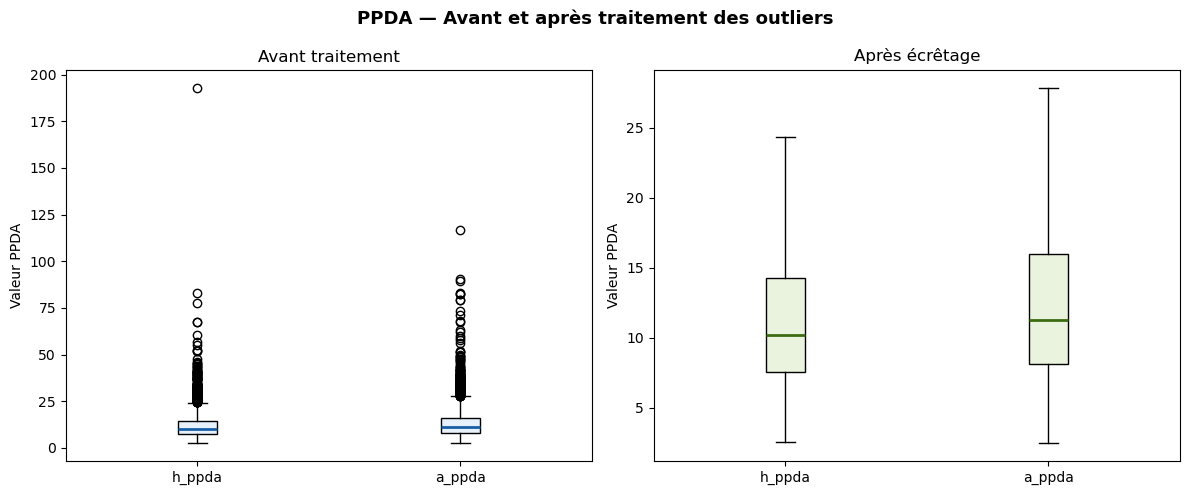

In [6]:
# ============================================================
# SECTION V : TRAITEMENT DES OUTLIERS
# ============================================================
display(Markdown("## Section V : Traitement des outliers"))

print("--- Méthode IQR appliquée sur le PPDA ---")
print("(Rappel : PPDA = intensité du pressing. Valeur basse = pressing intense)\n")

def traiter_outliers_iqr(df, colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    nb_outliers = df[(df[colonne] < borne_inf) | (df[colonne] > borne_sup)].shape[0]

    print(f"  {colonne} :")
    print(f"    Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}")
    print(f"    Borne inf = {borne_inf:.2f} | Borne sup = {borne_sup:.2f}")
    print(f"    Outliers détectés : {nb_outliers} ({nb_outliers/len(df)*100:.1f}%)")
    print(f"    Traitement : écrêtage (winsorization)")

    df[colonne] = df[colonne].clip(lower=borne_inf, upper=borne_sup)
    return df

df = traiter_outliers_iqr(df, 'h_ppda')
print()
df = traiter_outliers_iqr(df, 'a_ppda')

# --- Visualisation avant/après ---

df_original = pd.read_csv(r'C:\Users\user\Documents\Cours_et_TDs\Semestre2\Ana Données\TPs\Projet\understat_match_1524.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("PPDA — Avant et après traitement des outliers", fontsize=13, fontweight='bold')

axes[0].boxplot([df_original['h_ppda'], df_original['a_ppda']],
                tick_labels=['h_ppda', 'a_ppda'], patch_artist=True,
                boxprops=dict(facecolor='#E6F1FB'),
                medianprops=dict(color='#185FA5', linewidth=2))
axes[0].set_title("Avant traitement")
axes[0].set_ylabel("Valeur PPDA")

axes[1].boxplot([df['h_ppda'], df['a_ppda']],
                tick_labels=['h_ppda', 'a_ppda'], patch_artist=True,
                boxprops=dict(facecolor='#EAF3DE'),
                medianprops=dict(color='#3B6D11', linewidth=2))
axes[1].set_title("Après écrêtage")
axes[1].set_ylabel("Valeur PPDA")

plt.tight_layout()
plt.savefig('boxplot_ppda.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# SECTION VI : TRANSFORMATION DES DONNÉES
# ============================================================
display(Markdown("## Section VI : Transformation des données"))

# --- Conversion de la date ---
df['date'] = pd.to_datetime(df['date'])
df['annee'] = df['date'].dt.year
df['mois']  = df['date'].dt.month
print("Colonne 'date' convertie en datetime.")
print(f"Exemple : {df['date'].iloc[0]}")

# --- Création de nouvelles variables ---
print("\n--- Création de nouvelles variables ---")

# Résultat du match (point de vue domicile)
def get_result(row):
    if row['h_goals'] > row['a_goals']:
        return 'V'
    elif row['h_goals'] == row['a_goals']:
        return 'N'
    else:
        return 'D'

df['result']    = df.apply(get_result, axis=1)
df['h_points']  = df['result'].map({'V': 3, 'N': 1, 'D': 0})
df['a_points']  = df['result'].map({'V': 0, 'N': 1, 'D': 3})
df['total_goals'] = df['h_goals'] + df['a_goals']
df['goal_diff']   = df['h_goals'] - df['a_goals']
df['total_xg']    = df['h_xg'] + df['a_xg']
df['xg_diff']     = df['h_xg'] - df['a_xg']

# Ratio de précision des tirs
df['h_shot_ratio'] = (df['h_shotOnTarget'] / df['h_shot']).fillna(0).round(3)
df['a_shot_ratio'] = (df['a_shotOnTarget'] / df['a_shot']).fillna(0).round(3)

print("Variables créées : result, h_points, a_points, total_goals,")
print("                   goal_diff, total_xg, xg_diff, h_shot_ratio, a_shot_ratio")

print("\n--- Distribution des résultats ---")
dist = df['result'].value_counts()
pct  = (df['result'].value_counts(normalize=True) * 100).round(1)
for r, n, p in zip(dist.index, dist.values, pct.values):
    label = {'V': 'Victoire domicile', 'N': 'Match nul', 'D': 'Défaite domicile'}[r]
    print(f"  {label} : {n} matchs ({p}%)")


## Section VI : Transformation des données

Colonne 'date' convertie en datetime.
Exemple : 2015-08-08 15:45:00

--- Création de nouvelles variables ---
Variables créées : result, h_points, a_points, total_goals,
                   goal_diff, total_xg, xg_diff, h_shot_ratio, a_shot_ratio

--- Distribution des résultats ---
  Victoire domicile : 1536 matchs (44.9%)
  Défaite domicile : 1091 matchs (31.9%)
  Match nul : 793 matchs (23.2%)


In [8]:
# ============================================================
# SECTION VII : PRÉPARATION POUR L'ACP ET LE CLUSTERING
# ============================================================
display(Markdown("## Section VII : Préparation pour l'ACP et le Clustering"))

print("--- Standardisation des variables numériques ---")
print("(StandardScaler : moyenne=0, écart-type=1)\n")

vars_a_normaliser = [
    'h_goals', 'a_goals', 'h_xg', 'a_xg',
    'h_shot', 'a_shot', 'h_shotOnTarget', 'a_shotOnTarget',
    'h_deep', 'a_deep', 'h_ppda', 'a_ppda'
]

scaler = StandardScaler()
df_normalise = df.copy()
df_normalise[vars_a_normaliser] = scaler.fit_transform(df[vars_a_normaliser])

print("Moyennes après standardisation (≈ 0) :")
print(df_normalise[vars_a_normaliser].mean().round(4))
print("\nÉcarts-types après standardisation (≈ 1) :")
print(df_normalise[vars_a_normaliser].std().round(4))


## Section VII : Préparation pour l'ACP et le Clustering

--- Standardisation des variables numériques ---
(StandardScaler : moyenne=0, écart-type=1)

Moyennes après standardisation (≈ 0) :
h_goals           0.0
a_goals          -0.0
h_xg             -0.0
a_xg              0.0
h_shot           -0.0
a_shot            0.0
h_shotOnTarget   -0.0
a_shotOnTarget    0.0
h_deep            0.0
a_deep           -0.0
h_ppda           -0.0
a_ppda           -0.0
dtype: float64

Écarts-types après standardisation (≈ 1) :
h_goals           1.0001
a_goals           1.0001
h_xg              1.0001
a_xg              1.0001
h_shot            1.0001
a_shot            1.0001
h_shotOnTarget    1.0001
a_shotOnTarget    1.0001
h_deep            1.0001
a_deep            1.0001
h_ppda            1.0001
a_ppda            1.0001
dtype: float64


In [9]:
# ============================================================
# SECTION VIII : ANALYSE EXPLORATOIRE & CONNEXION AUX DÉCISIONS
# ============================================================
display(Markdown("## Section VIII : Analyse exploratoire & connexion aux décisions terrain"))

print("--- Avantage du terrain domicile ---")
total   = len(df)
vic_dom = (df['result'] == 'V').sum()
nul     = (df['result'] == 'N').sum()
vic_ext = (df['result'] == 'D').sum()
print(f"  Victoire domicile : {vic_dom/total*100:.1f}%")
print(f"  Match nul         : {nul/total*100:.1f}%")
print(f"  Victoire extérieur: {vic_ext/total*100:.1f}%")
print("  → L'avantage du terrain est-il réel ? L'analyse descriptive confirmera.")

print("\n--- Moyenne de buts par match ---")
print(f"  Buts domicile/match  : {df['h_goals'].mean():.2f}")
print(f"  Buts extérieur/match : {df['a_goals'].mean():.2f}")
print(f"  Buts totaux/match    : {df['total_goals'].mean():.2f}")

print("\n--- xG vs buts réels ---")
print(f"  xG domicile moyen  : {df['h_xg'].mean():.2f}  |  Buts réels : {df['h_goals'].mean():.2f}")
print(f"  xG extérieur moyen : {df['a_xg'].mean():.2f}  |  Buts réels : {df['a_goals'].mean():.2f}")
print("  → Les équipes marquent-elles autant que leur xG le prédit ?")


## Section VIII : Analyse exploratoire & connexion aux décisions terrain

--- Avantage du terrain domicile ---
  Victoire domicile : 44.9%
  Match nul         : 23.2%
  Victoire extérieur: 31.9%
  → L'avantage du terrain est-il réel ? L'analyse descriptive confirmera.

--- Moyenne de buts par match ---
  Buts domicile/match  : 1.56
  Buts extérieur/match : 1.26
  Buts totaux/match    : 2.82

--- xG vs buts réels ---
  xG domicile moyen  : 1.57  |  Buts réels : 1.56
  xG extérieur moyen : 1.26  |  Buts réels : 1.26
  → Les équipes marquent-elles autant que leur xG le prédit ?


In [10]:
# ============================================================
# SECTION IX : PIPELINE RÉCAPITULATIF & SAUVEGARDE
# ============================================================
display(Markdown("## Section IX : Pipeline de prétraitement complet (récapitulatif)"))

print("=" * 55)
print("  RÉCAPITULATIF DU PIPELINE DE PRÉTRAITEMENT")
print("=" * 55)
etapes = [
    ("I",   "Chargement des données",              f"{df.shape[0]} lignes, {df.shape[1]+6} colonnes initiales"),
    ("II",  "Exploration initiale",                "9 saisons, 49 équipes distinctes"),
    ("III", "Valeurs manquantes",                  "0 valeur manquante détectée"),
    ("IV",  "Doublons & colonnes inutiles",        "6 colonnes supprimées, 0 doublon"),
    ("V",   "Outliers PPDA",                       "Écrêtage IQR appliqué"),
    ("VI",  "Transformation & feature engineering","9 nouvelles variables créées"),
    ("VII", "Standardisation",                     "StandardScaler sur 12 variables"),
]
for num, etape, detail in etapes:
    print(f"  Section {num:<4} {etape:<35} → {detail}")

print("=" * 55)
print(f"\nDataset final : {df.shape[0]} lignes x {df.shape[1]} colonnes")

# Sauvegarde
df.to_csv('df_pretraite.csv', index=False)
df_normalise.to_csv('df_normalise.csv', index=False)
print("\nFichiers sauvegardés :")
print("  → df_pretraite.csv  (pour analyses descriptives et corrélations)")
print("  → df_normalise.csv  (pour ACP et clustering)")

## Section IX : Pipeline de prétraitement complet (récapitulatif)

  RÉCAPITULATIF DU PIPELINE DE PRÉTRAITEMENT
  Section I    Chargement des données              → 3420 lignes, 36 colonnes initiales
  Section II   Exploration initiale                → 9 saisons, 49 équipes distinctes
  Section III  Valeurs manquantes                  → 0 valeur manquante détectée
  Section IV   Doublons & colonnes inutiles        → 6 colonnes supprimées, 0 doublon
  Section V    Outliers PPDA                       → Écrêtage IQR appliqué
  Section VI   Transformation & feature engineering → 9 nouvelles variables créées
  Section VII  Standardisation                     → StandardScaler sur 12 variables

Dataset final : 3420 lignes x 30 colonnes

Fichiers sauvegardés :
  → df_pretraite.csv  (pour analyses descriptives et corrélations)
  → df_normalise.csv  (pour ACP et clustering)


In [11]:
# ============================================================
# PROJET ANALYSE DE DONNÉES — EPT 2025-2026
# Thématique : Performances en Premier League (2015-2023)
# Étape 2 : Analyse Descriptive
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

# Chargement du dataset prétraité
df = pd.read_csv(r'C:\Users\user\Documents\Cours_et_TDs\Semestre2\Ana Données\TPs\Projet\df_pretraite.csv')


# Style global des graphiques
sns.set_theme(style="whitegrid")
COULEUR_DOM  = '#185FA5'   # bleu  → domicile
COULEUR_EXT  = '#3B6D11'   # vert  → extérieur
COULEUR_NEU  = '#f29407'   # orange → neutre/total


## Section III : Effectifs et Fréquences

--- III.1 Distribution des résultats (du point de vue domicile) ---


,Résultat,Code,Effectif,Fréquence %
0,Victoire domicile,V,1536,44.9
1,Match nul,N,793,23.2
2,Victoire extérieur,D,1091,31.9


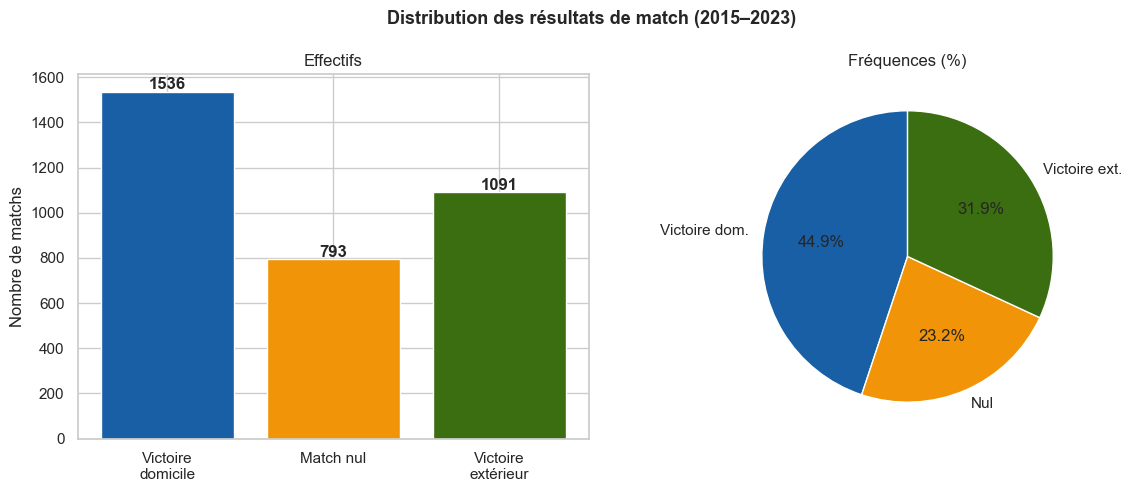


--- III.2 Effectifs par saison ---
season
2015    380
2016    380
2017    380
2018    380
2019    380
2020    380
2021    380
2022    380
2023    380
Name: count, dtype: int64

--- III.3 Top 10 équipes — Victoires domicile + extérieur ---
Manchester City      244
Liverpool            212
Arsenal              191
Tottenham            185
Manchester United    177
Chelsea              173
West Ham             123
Leicester            123
Everton              118
Crystal Palace       106
Name: count, dtype: int64


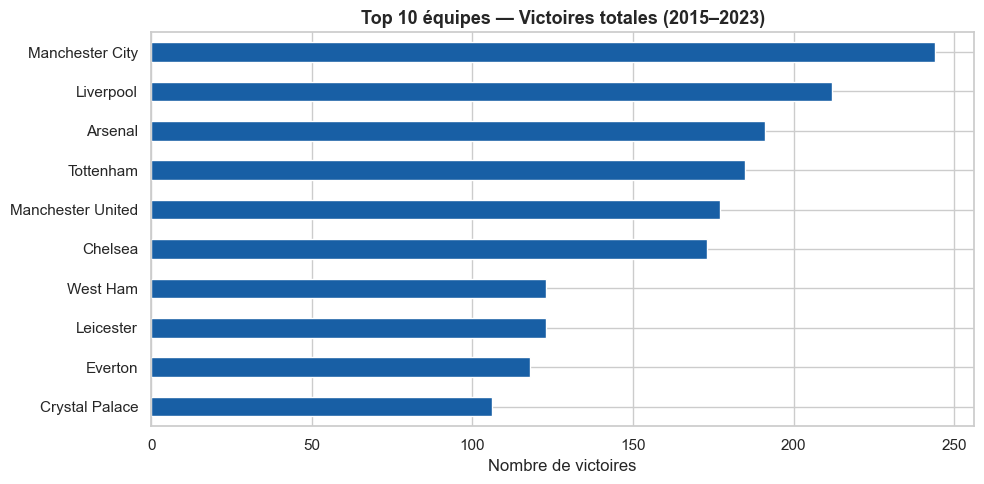

In [12]:
# ============================================================
# SECTION III : EFFECTIFS ET FRÉQUENCES
# ============================================================
display(Markdown("## Section III : Effectifs et Fréquences"))

# --- III.1 Distribution des résultats ---
print("--- III.1 Distribution des résultats (du point de vue domicile) ---")
effectifs_result = df['result'].value_counts()
frequences_result = (df['result'].value_counts(normalize=True) * 100).round(1)

tableau_result = pd.DataFrame({
    'Résultat'   : ['Victoire domicile', 'Match nul', 'Victoire extérieur'],
    'Code'       : ['V', 'N', 'D'],
    'Effectif'   : [effectifs_result.get('V',0), effectifs_result.get('N',0), effectifs_result.get('D',0)],
    'Fréquence %': [frequences_result.get('V',0), frequences_result.get('N',0), frequences_result.get('D',0)]
})
display(tableau_result)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribution des résultats de match (2015–2023)", fontsize=13, fontweight='bold')

# Barplot
axes[0].bar(['Victoire\ndomicile', 'Match nul', 'Victoire\nextérieur'],
            tableau_result['Effectif'],
            color=[COULEUR_DOM, COULEUR_NEU, COULEUR_EXT], edgecolor='white')
axes[0].set_title("Effectifs")
axes[0].set_ylabel("Nombre de matchs")
for i, v in enumerate(tableau_result['Effectif']):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(tableau_result['Fréquence %'],
            labels=['Victoire dom.', 'Nul', 'Victoire ext.'],
            autopct='%1.1f%%',
            colors=[COULEUR_DOM, COULEUR_NEU, COULEUR_EXT],
            startangle=90)
axes[1].set_title("Fréquences (%)")
plt.tight_layout()
plt.savefig('III_1_distribution_resultats.png', dpi=150, bbox_inches='tight')
plt.show()

# --- III.2 Nombre de matchs par saison ---
print("\n--- III.2 Effectifs par saison ---")
matchs_par_saison = df['season'].value_counts().sort_index()
print(matchs_par_saison)


# --- III.3 Top 10 équipes par nombre de victoires ---
print("\n--- III.3 Top 10 équipes — Victoires domicile + extérieur ---")
vic_dom = df[df['result'] == 'V']['team_h'].value_counts()
vic_ext = df[df['result'] == 'D']['team_a'].value_counts()
victoires_totales = (vic_dom.add(vic_ext, fill_value=0)
                     .sort_values(ascending=False)
                     .head(10)
                     .astype(int))
print(victoires_totales)

fig, ax = plt.subplots(figsize=(10, 5))
victoires_totales.plot(kind='barh', ax=ax, color=COULEUR_DOM, edgecolor='white')
ax.set_title("Top 10 équipes — Victoires totales (2015–2023)", fontsize=13, fontweight='bold')
ax.set_xlabel("Nombre de victoires")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('III_3_top10_victoires.png', dpi=150, bbox_inches='tight')
plt.show()


## Section IV : Indicateurs de Tendance Centrale

,Variable,Moyenne,Médiane,Mode
0,Buts domicile,1.556,1.000,1.000
1,Buts extérieur,1.262,1.000,1.000
2,xG domicile,1.565,1.405,1.038
3,xG extérieur,1.258,1.118,0.291
4,Tirs domicile,13.943,13.000,14.000
5,Tirs extérieur,11.437,11.000,9.000
6,Tirs cadrés dom.,4.773,4.000,4.000
7,Tirs cadrés ext.,3.997,4.000,3.000
8,Deep passes dom.,7.562,6.000,5.000
9,Deep passes ext.,6.234,5.000,4.000



--- Comparaison domicile vs extérieur ---
Buts moyens domicile  : 1.556
Buts moyens extérieur : 1.262
xG moyen domicile     : 1.565
xG moyen extérieur    : 1.258
Buts totaux / match   : 2.818


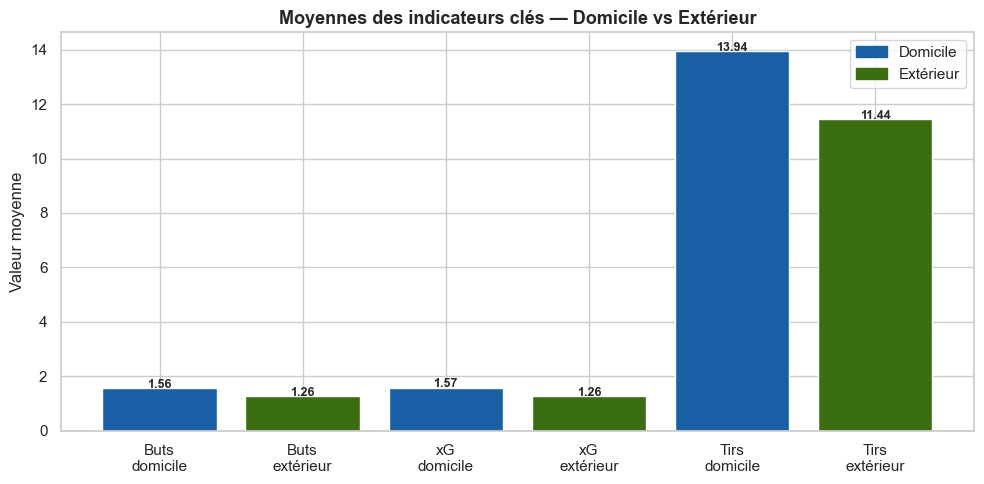

In [13]:
# ============================================================
# SECTION IV : INDICATEURS DE TENDANCE CENTRALE
# ============================================================
display(Markdown("## Section IV : Indicateurs de Tendance Centrale"))

vars_analyse = {
    'Buts domicile'       : 'h_goals',
    'Buts extérieur'      : 'a_goals',
    'xG domicile'         : 'h_xg',
    'xG extérieur'        : 'a_xg',
    'Tirs domicile'       : 'h_shot',
    'Tirs extérieur'      : 'a_shot',
    'Tirs cadrés dom.'    : 'h_shotOnTarget',
    'Tirs cadrés ext.'    : 'a_shotOnTarget',
    'Deep passes dom.'    : 'h_deep',
    'Deep passes ext.'    : 'a_deep',
    'PPDA domicile'       : 'h_ppda',
    'PPDA extérieur'      : 'a_ppda',
    'Buts totaux'         : 'total_goals',
}

tableau_centrale = pd.DataFrame({
    'Variable' : list(vars_analyse.keys()),
    'Moyenne'  : [df[c].mean().round(3) for c in vars_analyse.values()],
    'Médiane'  : [round(df[c].median(),3) for c in vars_analyse.values()],
    'Mode'     : [df[c].mode()[0].round(3) for c in vars_analyse.values()],
})
display(tableau_centrale)

# Comparaison moyenne buts domicile vs extérieur
print("\n--- Comparaison domicile vs extérieur ---")
print(f"Buts moyens domicile  : {df['h_goals'].mean():.3f}")
print(f"Buts moyens extérieur : {df['a_goals'].mean():.3f}")
print(f"xG moyen domicile     : {df['h_xg'].mean():.3f}")
print(f"xG moyen extérieur    : {df['a_xg'].mean():.3f}")
print(f"Buts totaux / match   : {df['total_goals'].mean():.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Buts\ndomicile', 'Buts\nextérieur', 'xG\ndomicile', 'xG\nextérieur',
              'Tirs\ndomicile', 'Tirs\nextérieur']
valeurs    = [df['h_goals'].mean(), df['a_goals'].mean(),
              df['h_xg'].mean(),    df['a_xg'].mean(),
              df['h_shot'].mean(),  df['a_shot'].mean()]
couleurs   = [COULEUR_DOM, COULEUR_EXT] * 3

bars = ax.bar(categories, valeurs, color=couleurs, edgecolor='white')
ax.set_title("Moyennes des indicateurs clés — Domicile vs Extérieur",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Valeur moyenne")
for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

patch_dom = mpatches.Patch(color=COULEUR_DOM, label='Domicile')
patch_ext = mpatches.Patch(color=COULEUR_EXT, label='Extérieur')
ax.legend(handles=[patch_dom, patch_ext])
plt.tight_layout()
plt.savefig('IV_tendance_centrale.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# SECTION V : INDICATEURS DE DISPERSION
# ============================================================
display(Markdown("## Section V : Indicateurs de Dispersion"))

tableau_dispersion = pd.DataFrame({
    'Variable'    : list(vars_analyse.keys()),
    'Écart-type'  : [round(df[c].std(),3)  for c in vars_analyse.values()],
    'Variance'    : [round(df[c].var(),3)  for c in vars_analyse.values()],
    'Min'         : [round(df[c].min(),3)  for c in vars_analyse.values()],
    'Max'         : [round(df[c].max(),3)  for c in vars_analyse.values()],
    'Étendue'     : [round(df[c].max() - df[c].min(),3) for c in vars_analyse.values()],
    'CV (%)'      : [(df[c].std() / df[c].mean() * 100).round(1) for c in vars_analyse.values()],
})
display(tableau_dispersion)

print("\n--- Interprétation du Coefficient de Variation (CV) ---")
print("CV < 15%  → faible dispersion (variable homogène)")
print("CV 15-30% → dispersion modérée")
print("CV > 30%  → forte dispersion (variable très variable)")


## Section V : Indicateurs de Dispersion

,Variable,Écart-type,Variance,Min,Max,Étendue,CV (%)
0,Buts domicile,1.327,1.760,0.000,9.000,9.000,85.2
1,Buts extérieur,1.215,1.477,0.000,9.000,9.000,96.3
2,xG domicile,0.924,0.853,0.000,6.672,6.672,59.0
3,xG extérieur,0.811,0.657,0.000,5.518,5.518,64.5
4,Tirs domicile,5.758,33.157,0.000,38.000,38.000,41.3
5,Tirs extérieur,5.002,25.025,0.000,31.000,31.000,43.7
6,Tirs cadrés dom.,2.670,7.131,0.000,17.000,17.000,55.9
7,Tirs cadrés ext.,2.370,5.619,0.000,15.000,15.000,59.3
8,Deep passes dom.,4.970,24.704,0.000,37.000,37.000,65.7
9,Deep passes ext.,4.270,18.230,0.000,28.000,28.000,68.5



--- Interprétation du Coefficient de Variation (CV) ---
CV < 15%  → faible dispersion (variable homogène)
CV 15-30% → dispersion modérée
CV > 30%  → forte dispersion (variable très variable)


## Section VI : Moments d'ordre p, Asymétrie et Aplatissement

,Variable,Moyenne,Variance,Skewness,Kurtosis
0,Buts dom.,1.556,1.760,0.956,1.142
1,Buts ext.,1.262,1.477,1.078,1.468
2,xG dom.,1.565,0.853,0.882,0.932
3,xG ext.,1.258,0.657,1.043,1.278
4,Tirs dom.,13.943,33.157,0.609,0.435
5,Tirs ext.,11.437,25.025,0.592,0.256
6,PPDA dom.,11.512,28.536,0.897,0.062
7,PPDA ext.,12.757,38.666,0.918,0.106
8,Buts totaux,2.818,2.794,0.533,0.220



--- Interprétation ---
Skewness > 0  → distribution asymétrique à droite (queue vers les grandes valeurs)
Skewness < 0  → distribution asymétrique à gauche
Skewness ≈ 0  → distribution symétrique
Kurtosis > 0  → distribution leptokurtique (pic prononcé, queues épaisses)
Kurtosis < 0  → distribution platykurtique (pic aplati)
Kurtosis ≈ 0  → distribution mésokurtique (normale)


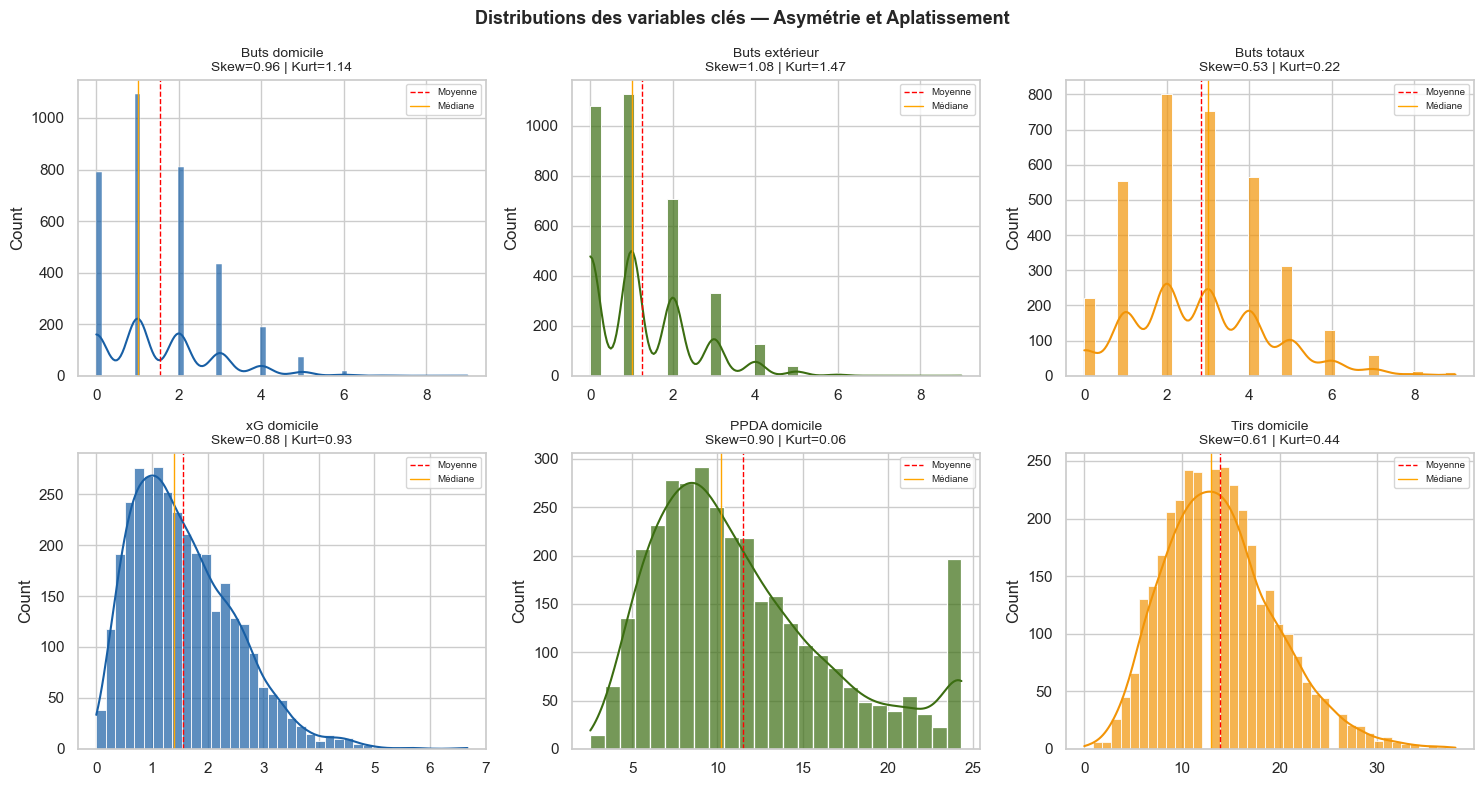

In [15]:
# ============================================================
# SECTION VI : ASYMÉTRIE ET APLATISSEMENT
# ============================================================
display(Markdown("## Section VI : Moments d'ordre p, Asymétrie et Aplatissement"))

vars_moments = ['h_goals', 'a_goals', 'h_xg', 'a_xg',
                'h_shot', 'a_shot', 'h_ppda', 'a_ppda', 'total_goals']
noms_moments  = ['Buts dom.', 'Buts ext.', 'xG dom.', 'xG ext.',
                 'Tirs dom.', 'Tirs ext.', 'PPDA dom.', 'PPDA ext.', 'Buts totaux']

tableau_moments = pd.DataFrame({
    'Variable'  : noms_moments,
    'Moyenne'   : [df[c].mean().round(3)             for c in vars_moments],
    'Variance'  : [round(df[c].var(),3)              for c in vars_moments],
    'Skewness'  : [stats.skew(df[c]).round(3)        for c in vars_moments],
    'Kurtosis'  : [stats.kurtosis(df[c]).round(3)    for c in vars_moments],
})
display(tableau_moments)

print("\n--- Interprétation ---")
print("Skewness > 0  → distribution asymétrique à droite (queue vers les grandes valeurs)")
print("Skewness < 0  → distribution asymétrique à gauche")
print("Skewness ≈ 0  → distribution symétrique")
print("Kurtosis > 0  → distribution leptokurtique (pic prononcé, queues épaisses)")
print("Kurtosis < 0  → distribution platykurtique (pic aplati)")
print("Kurtosis ≈ 0  → distribution mésokurtique (normale)")

# Visualisation distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distributions des variables clés — Asymétrie et Aplatissement",
             fontsize=13, fontweight='bold')

vars_plot = ['h_goals', 'a_goals', 'total_goals', 'h_xg', 'h_ppda', 'h_shot']
titres    = ['Buts domicile', 'Buts extérieur', 'Buts totaux',
             'xG domicile', 'PPDA domicile', 'Tirs domicile']
couleurs_plot = [COULEUR_DOM, COULEUR_EXT, COULEUR_NEU,
                 COULEUR_DOM, COULEUR_EXT, COULEUR_NEU]

for ax, var, titre, coul in zip(axes.flatten(), vars_plot, titres, couleurs_plot):
    sns.histplot(df[var], kde=True, ax=ax, color=coul, alpha=0.7)
    sk = stats.skew(df[var])
    ku = stats.kurtosis(df[var])
    ax.set_title(f"{titre}\nSkew={sk:.2f} | Kurt={ku:.2f}", fontsize=10)
    ax.set_xlabel("")
    ax.axvline(df[var].mean(),   color='red',    linestyle='--', linewidth=1, label='Moyenne')
    ax.axvline(df[var].median(), color='orange', linestyle='-',  linewidth=1, label='Médiane')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('VI_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Section VII : Quantiles et Boxplot

--- Tableau des quantiles ---


,Buts dom.,Buts ext.,xG dom.,xG ext.,Tirs dom.,Tirs ext.,Buts totaux
Q10,0.0,0.0,0.51,0.34,7.0,6.0,1.0
Q25,1.0,0.0,0.85,0.64,10.0,8.0,2.0
Q50,1.0,1.0,1.40,1.12,13.0,11.0,3.0
Q75,2.0,2.0,2.15,1.71,17.0,15.0,4.0
Q90,3.0,3.0,2.81,2.36,22.0,18.0,5.0


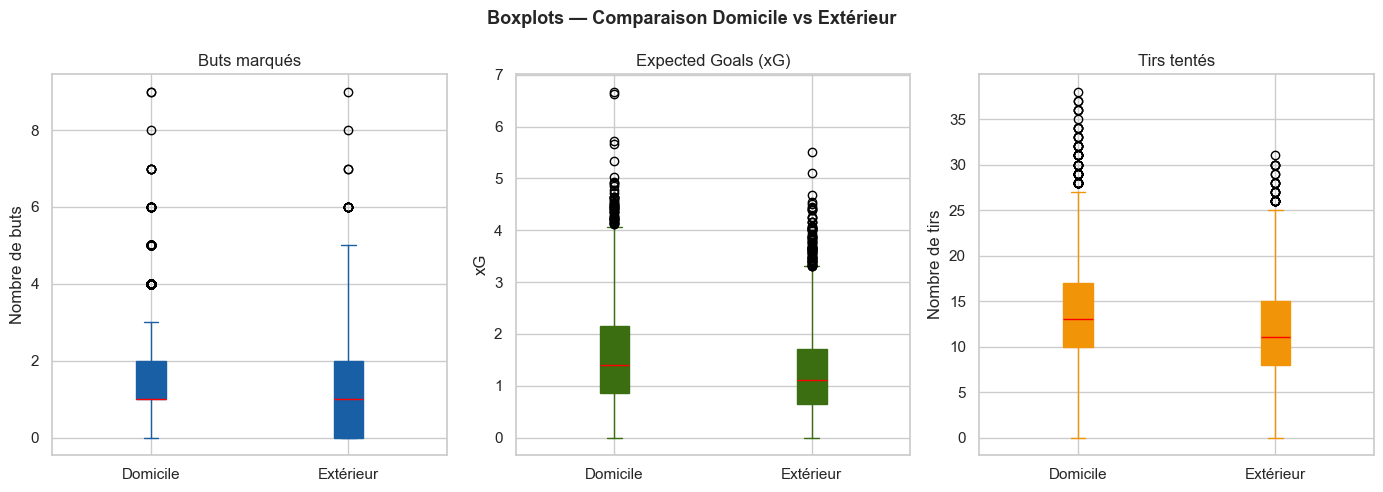

In [16]:
# ============================================================
# SECTION VII : QUANTILES ET BOXPLOTS
# ============================================================
display(Markdown("## Section VII : Quantiles et Boxplot"))

print("--- Tableau des quantiles ---")
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
vars_q = ['h_goals', 'a_goals', 'h_xg', 'a_xg', 'h_shot', 'a_shot', 'total_goals']
noms_q = ['Buts dom.', 'Buts ext.', 'xG dom.', 'xG ext.',
          'Tirs dom.', 'Tirs ext.', 'Buts totaux']

tableau_quantiles = pd.DataFrame(
    {nom: [df[col].quantile(q) for q in quantiles]
     for nom, col in zip(noms_q, vars_q)},
    index=[f'Q{int(q*100)}' for q in quantiles]
).round(2)
display(tableau_quantiles)

# Boxplot domicile vs extérieur — buts
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Boxplots — Comparaison Domicile vs Extérieur", fontsize=13, fontweight='bold')

# Buts
data_buts = pd.DataFrame({'Domicile': df['h_goals'], 'Extérieur': df['a_goals']})
data_buts.plot(kind='box', ax=axes[0], color={'boxes': COULEUR_DOM, 'medians': 'red',
               'whiskers': COULEUR_DOM, 'caps': COULEUR_DOM}, patch_artist=True)
axes[0].set_title("Buts marqués")
axes[0].set_ylabel("Nombre de buts")

# xG
data_xg = pd.DataFrame({'Domicile': df['h_xg'], 'Extérieur': df['a_xg']})
data_xg.plot(kind='box', ax=axes[1], color={'boxes': COULEUR_EXT, 'medians': 'red',
             'whiskers': COULEUR_EXT, 'caps': COULEUR_EXT}, patch_artist=True)
axes[1].set_title("Expected Goals (xG)")
axes[1].set_ylabel("xG")

# Tirs
data_shot = pd.DataFrame({'Domicile': df['h_shot'], 'Extérieur': df['a_shot']})
data_shot.plot(kind='box', ax=axes[2], color={'boxes': COULEUR_NEU, 'medians': 'red',
              'whiskers': COULEUR_NEU, 'caps': COULEUR_NEU}, patch_artist=True)
axes[2].set_title("Tirs tentés")
axes[2].set_ylabel("Nombre de tirs")

plt.tight_layout()
plt.savefig('VII_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section VIII : Indice de Gini & Courbe de Lorenz

--- Application : inégalité des points cumulés par équipe ---
Question : Quelques équipes dominent-elles toute la Premier League ?

Points cumulés par équipe (2015–2023) :


,Equipe,Points
0,Manchester City,782
1,Liverpool,717
2,Arsenal,638
3,Tottenham,622
4,Manchester United,615
5,Chelsea,599
6,West Ham,453
7,Everton,442
8,Leicester,438
9,Crystal Palace,405



Indice de Gini : 0.4301
Interprétation :
  0 → parfaite égalité (toutes les équipes ont les mêmes points)
  1 → inégalité totale (une seule équipe a tous les points)


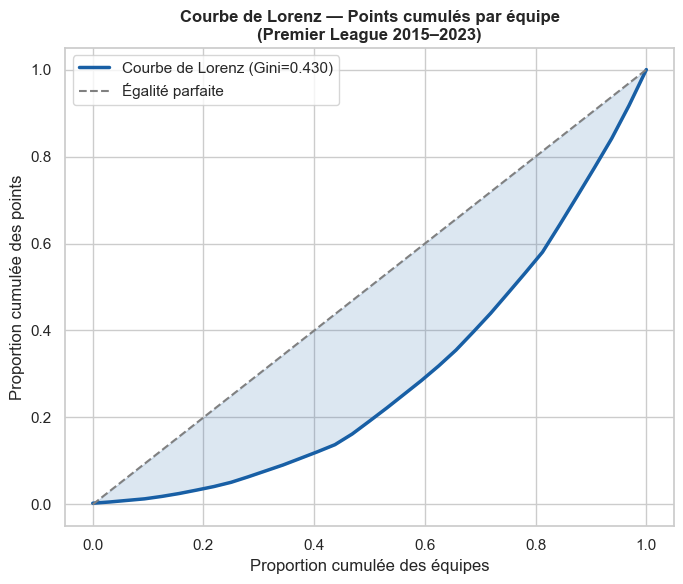

In [17]:
# ============================================================
# SECTION VIII : INDICE DE GINI & COURBE DE LORENZ
# ============================================================
display(Markdown("## Section VIII : Indice de Gini & Courbe de Lorenz"))

print("--- Application : inégalité des points cumulés par équipe ---")
print("Question : Quelques équipes dominent-elles toute la Premier League ?\n")

# Calcul des points cumulés par équipe sur toute la période
points_dom = df.groupby('team_h')['h_points'].sum()
points_ext = df.groupby('team_a')['a_points'].sum()
points_totaux = (points_dom.add(points_ext, fill_value=0)
                 .sort_values()
                 .reset_index())
points_totaux.columns = ['Equipe', 'Points']

print("Points cumulés par équipe (2015–2023) :")
display(points_totaux.sort_values('Points', ascending=False).reset_index(drop=True))

# Calcul de l'indice de Gini
def gini(valeurs):
    valeurs = np.sort(valeurs)
    n = len(valeurs)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * valeurs) / (n * np.sum(valeurs))) - (n + 1) / n

G = gini(points_totaux['Points'].values)
print(f"\nIndice de Gini : {G:.4f}")
print("Interprétation :")
print("  0 → parfaite égalité (toutes les équipes ont les mêmes points)")
print("  1 → inégalité totale (une seule équipe a tous les points)")

# Courbe de Lorenz
vals = np.sort(points_totaux['Points'].values)
cumul_equipes = np.linspace(0, 1, len(vals))
cumul_points  = np.cumsum(vals) / vals.sum()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(cumul_equipes, cumul_points,
        color=COULEUR_DOM, linewidth=2.5, label=f'Courbe de Lorenz (Gini={G:.3f})')
ax.plot([0, 1], [0, 1],
        color='gray', linestyle='--', linewidth=1.5, label='Égalité parfaite')
ax.fill_between(cumul_equipes, cumul_points, cumul_equipes, alpha=0.15, color=COULEUR_DOM)
ax.set_title("Courbe de Lorenz — Points cumulés par équipe\n(Premier League 2015–2023)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Proportion cumulée des équipes")
ax.set_ylabel("Proportion cumulée des points")
ax.legend()
plt.tight_layout()
plt.savefig('VIII_lorenz.png', dpi=150, bbox_inches='tight')
plt.show()


## Section IX : Mesure de la relation entre variables (Covariance & Corrélation)

--- Matrice de Covariance ---


,Buts dom.,Buts ext.,xG dom.,xG ext.,Tirs dom.,Tirs ext.,Cadrés dom.,Cadrés ext.,Deep dom.,Deep ext.,PPDA dom.,PPDA ext.
Buts dom.,1.76,-0.22,0.77,-0.24,2.52,-1.26,2.14,-0.50,2.11,-1.04,-0.81,1.70
Buts ext.,-0.22,1.48,-0.22,0.64,-1.14,2.17,-0.53,1.74,-0.88,1.50,1.07,-0.98
xG dom.,0.77,-0.22,0.85,-0.21,3.57,-1.49,1.76,-0.54,2.52,-1.12,-1.27,1.87
xG ext.,-0.24,0.64,-0.21,0.66,-1.38,2.67,-0.54,1.32,-0.96,1.75,1.24,-1.25
Tirs dom.,2.52,-1.14,3.57,-1.38,33.16,-12.41,10.63,-3.89,18.26,-9.73,-12.99,14.59
Tirs ext.,-1.26,2.17,-1.49,2.67,-12.41,25.02,-4.01,8.16,-9.27,13.20,10.58,-12.99
Cadrés dom.,2.14,-0.53,1.76,-0.54,10.63,-4.01,7.13,-1.40,6.41,-3.08,-3.85,5.16
Cadrés ext.,-0.50,1.74,-0.54,1.32,-3.89,8.16,-1.40,5.62,-2.72,4.61,3.44,-3.79
Deep dom.,2.11,-0.88,2.52,-0.96,18.26,-9.27,6.41,-2.72,24.70,-7.27,-10.48,14.30
Deep ext.,-1.04,1.50,-1.12,1.75,-9.73,13.20,-3.08,4.61,-7.27,18.23,10.52,-9.60



--- Matrice de Corrélation (Pearson) ---


,Buts dom.,Buts ext.,xG dom.,xG ext.,Tirs dom.,Tirs ext.,Cadrés dom.,Cadrés ext.,Deep dom.,Deep ext.,PPDA dom.,PPDA ext.
Buts dom.,1.000,-0.137,0.632,-0.219,0.330,-0.190,0.604,-0.160,0.320,-0.184,-0.114,0.206
Buts ext.,-0.137,1.000,-0.196,0.649,-0.163,0.358,-0.164,0.604,-0.145,0.289,0.165,-0.130
xG dom.,0.632,-0.196,1.000,-0.279,0.671,-0.322,0.713,-0.246,0.550,-0.283,-0.257,0.326
xG ext.,-0.219,0.649,-0.279,1.000,-0.295,0.658,-0.247,0.686,-0.238,0.506,0.286,-0.247
Tirs dom.,0.330,-0.163,0.671,-0.295,1.000,-0.431,0.692,-0.285,0.638,-0.396,-0.422,0.408
Tirs ext.,-0.190,0.358,-0.322,0.658,-0.431,1.000,-0.301,0.688,-0.373,0.618,0.396,-0.418
Cadrés dom.,0.604,-0.164,0.713,-0.247,0.692,-0.301,1.000,-0.221,0.483,-0.270,-0.270,0.311
Cadrés ext.,-0.160,0.604,-0.246,0.686,-0.285,0.688,-0.221,1.000,-0.231,0.456,0.272,-0.257
Deep dom.,0.320,-0.145,0.550,-0.238,0.638,-0.373,0.483,-0.231,1.000,-0.342,-0.395,0.463
Deep ext.,-0.184,0.289,-0.283,0.506,-0.396,0.618,-0.270,0.456,-0.342,1.000,0.461,-0.362


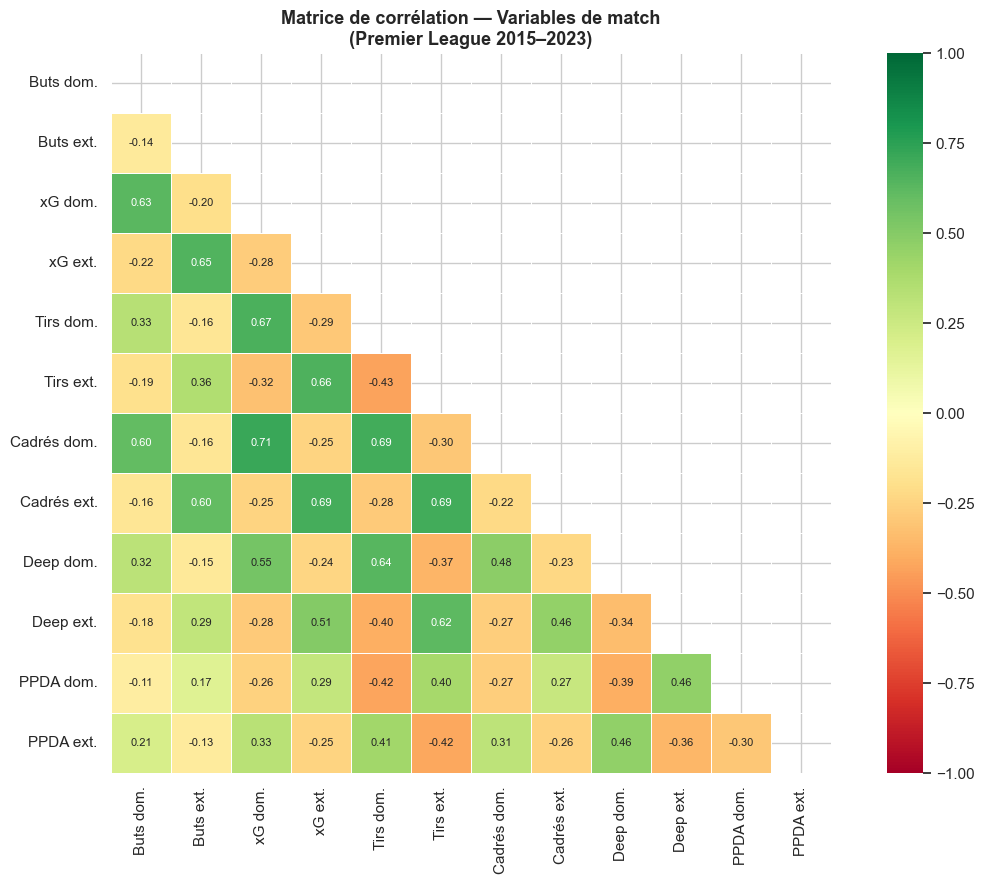


--- Corrélations clés à interpréter ---
  xG domicile ↔ Buts domicile : r = 0.632 → corrélation modérée positive
  xG extérieur ↔ Buts extérieur : r = 0.649 → corrélation modérée positive
  Tirs domicile ↔ Buts domicile : r = 0.330 → corrélation faible positive
  Tirs cadrés dom. ↔ Buts domicile : r = 0.604 → corrélation modérée positive
  Deep passes dom. ↔ xG domicile : r = 0.550 → corrélation modérée positive
  PPDA domicile ↔ xG extérieur : r = 0.286 → corrélation faible positive

✓ Analyse descriptive terminée.
  Graphiques sauvegardés dans le dossier courant.
  Prochaine étape : Analyse Factorielle (ACP)


In [18]:
# ============================================================
# SECTION IX : COVARIANCE ET CORRÉLATION
# ============================================================
display(Markdown("## Section IX : Mesure de la relation entre variables (Covariance & Corrélation)"))

vars_corr = ['h_goals', 'a_goals', 'h_xg', 'a_xg',
             'h_shot', 'a_shot', 'h_shotOnTarget', 'a_shotOnTarget',
             'h_deep', 'a_deep', 'h_ppda', 'a_ppda']
noms_corr  = ['Buts dom.', 'Buts ext.', 'xG dom.', 'xG ext.',
              'Tirs dom.', 'Tirs ext.', 'Cadrés dom.', 'Cadrés ext.',
              'Deep dom.', 'Deep ext.', 'PPDA dom.', 'PPDA ext.']

df_corr = df[vars_corr].copy()
df_corr.columns = noms_corr

# --- Matrice de covariance ---
print("--- Matrice de Covariance ---")
display(df_corr.cov().round(2))

# --- Matrice de corrélation ---
print("\n--- Matrice de Corrélation (Pearson) ---")
matrice_corr = df_corr.corr()
display(matrice_corr.round(3))

# Heatmap de corrélation
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(matrice_corr, dtype=bool))
sns.heatmap(matrice_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title("Matrice de corrélation — Variables de match\n(Premier League 2015–2023)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('IX_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Corrélations clés commentées ---
print("\n--- Corrélations clés à interpréter ---")
paires = [
    ('xG dom.',    'Buts dom.',    "xG domicile ↔ Buts domicile"),
    ('xG ext.',    'Buts ext.',    "xG extérieur ↔ Buts extérieur"),
    ('Tirs dom.',  'Buts dom.',    "Tirs domicile ↔ Buts domicile"),
    ('Cadrés dom.','Buts dom.',    "Tirs cadrés dom. ↔ Buts domicile"),
    ('Deep dom.',  'xG dom.',      "Deep passes dom. ↔ xG domicile"),
    ('PPDA dom.',  'xG ext.',      "PPDA domicile ↔ xG extérieur"),
]
for v1, v2, label in paires:
    r = matrice_corr.loc[v1, v2]
    if abs(r) >= 0.7:
        force = "forte"
    elif abs(r) >= 0.4:
        force = "modérée"
    else:
        force = "faible"
    sens = "positive" if r > 0 else "négative"
    print(f"  {label} : r = {r:.3f} → corrélation {force} {sens}")

print("\n✓ Analyse descriptive terminée.")
print("  Graphiques sauvegardés dans le dossier courant.")
print("  Prochaine étape : Analyse Factorielle (ACP)")

In [19]:
# ============================================================
# PROJET ANALYSE DE DONNÉES — EPT 2025-2026
# Thématique : Performances en Premier League (2015-2023)
# Étape 3 : Analyse Factorielle, Non Supervisée & Séries Temporelles
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Analyse factorielle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score

# Séries temporelles
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Warnings
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown

# Style global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
COLORS = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

# Chargement des datasets
df = pd.read_csv(r'C:\Users\user\Documents\Cours_et_TDs\Semestre2\Ana Données\TPs\Projet\df_pretraite.csv')

df_norm = pd.read_csv(r'C:\Users\user\Documents\Cours_et_TDs\Semestre2\Ana Données\TPs\Projet\df_normalise.csv')
df['date']  = pd.to_datetime(df['date'])

print("Datasets chargés avec succès.")
print(f"df          : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"df_normalise: {df_norm.shape[0]} lignes x {df_norm.shape[1]} colonnes")

# Variables numériques utilisées pour ACP et Clustering
VARS_NUM = ['h_goals', 'a_goals', 'h_xg', 'a_xg',
            'h_shot', 'a_shot', 'h_shotOnTarget', 'a_shotOnTarget',
            'h_deep', 'a_deep', 'h_ppda', 'a_ppda']

NOMS_VARS = ['Buts dom.', 'Buts ext.', 'xG dom.', 'xG ext.',
             'Tirs dom.', 'Tirs ext.', 'Cadrés dom.', 'Cadrés ext.',
             'Deep dom.', 'Deep ext.', 'PPDA dom.', 'PPDA ext.']


Datasets chargés avec succès.
df          : 3420 lignes x 30 colonnes
df_normalise: 3420 lignes x 30 colonnes


## Section II : Analyse en Composantes Principales (ACP)

### II.1 Préparation des données

Matrice X prête pour l'ACP :
  Dimensions : 3420 observations x 12 variables
  Moyenne des colonnes (≈ 0) : [ 0.  0. -0.  0. -0.  0. -0.  0.  0. -0. -0. -0.]
  Écart-type des colonnes (≈ 1) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### II.2 Calcul de l'ACP


Variance expliquée par composante :
  CP1 : 42.21%  (cumulée : 42.21%)
  CP2 : 16.94%  (cumulée : 59.15%)
  CP3 : 9.97%  (cumulée : 69.12%)
  CP4 : 5.99%  (cumulée : 75.12%)
  CP5 : 5.43%  (cumulée : 80.55%)
  CP6 : 4.54%  (cumulée : 85.09%)
  CP7 : 3.56%  (cumulée : 88.65%)
  CP8 : 3.46%  (cumulée : 92.11%)
  CP9 : 2.45%  (cumulée : 94.56%)
  CP10 : 2.25%  (cumulée : 96.82%)
  CP11 : 1.63%  (cumulée : 98.44%)
  CP12 : 1.56%  (cumulée : 100.00%)


### II.3 Choix du nombre de composantes — Règle de Kaiser & Coude

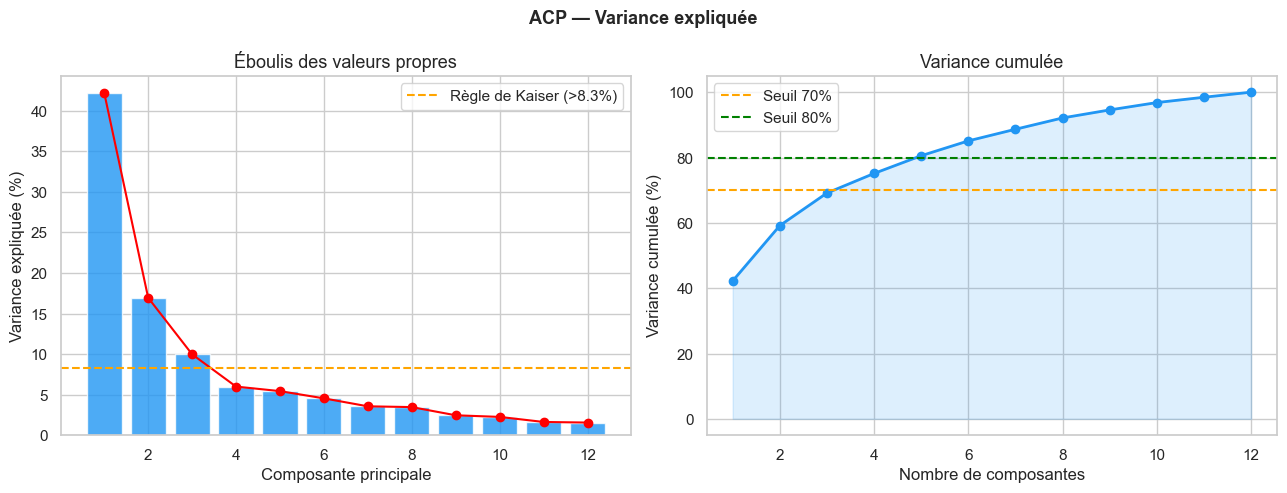


Nombre de composantes retenues (seuil 75%) : 4
Variance expliquée cumulée : 75.12%


### II.4 Cercle des corrélations

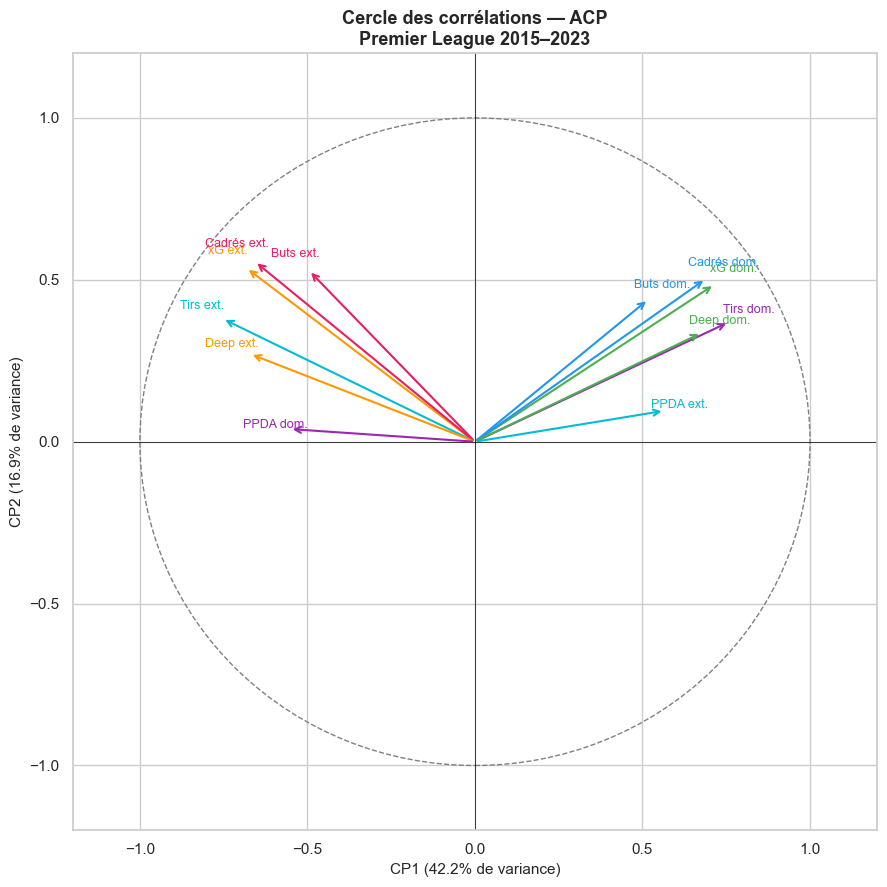

### II.5 Projection des matchs sur le plan factoriel

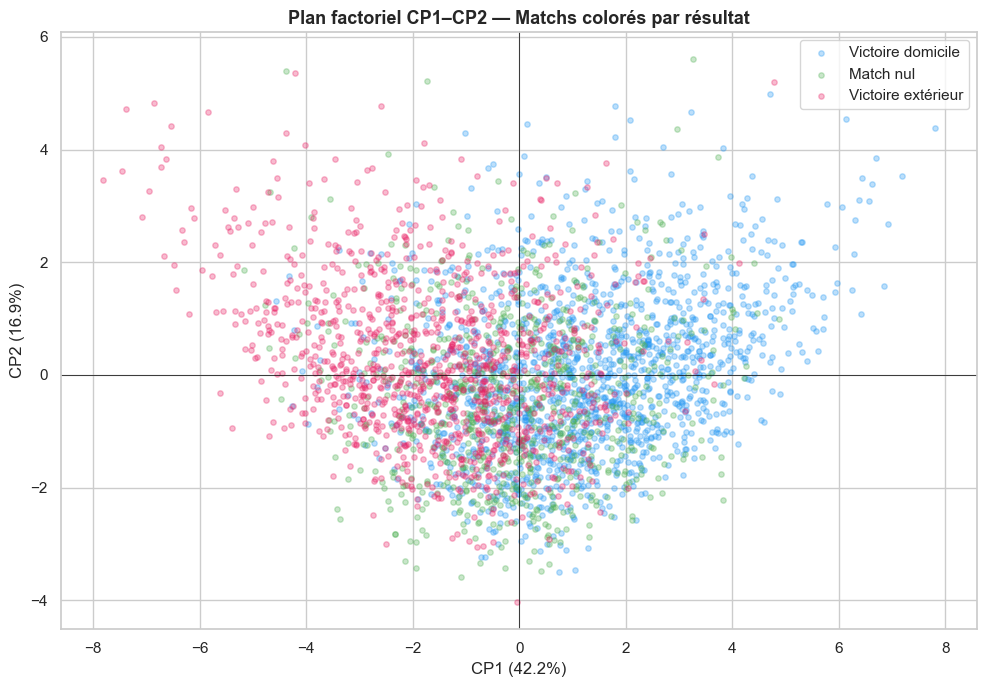

### II.6 Contributions des variables aux composantes

,CP1 (%),CP2 (%)
Tirs dom.,9.8,8.1
Tirs ext.,9.7,8.4
xG dom.,9.2,10.7
Cadrés dom.,8.9,11.1
xG ext.,8.8,11.8
Deep dom.,8.8,7.4
Deep ext.,8.7,6.0
Cadrés ext.,8.5,12.3
PPDA ext.,7.3,2.1
PPDA dom.,7.1,0.8


In [20]:
# ============================================================
# SECTION II : ANALYSE EN COMPOSANTES PRINCIPALES (ACP)
# ============================================================
display(Markdown("## Section II : Analyse en Composantes Principales (ACP)"))

# --- II.1 Préparation des données ---
display(Markdown("### II.1 Préparation des données"))

X = df_norm[VARS_NUM].values

print("Matrice X prête pour l'ACP :")
print(f"  Dimensions : {X.shape[0]} observations x {X.shape[1]} variables")
print(f"  Moyenne des colonnes (≈ 0) : {X.mean(axis=0).round(3)}")
print(f"  Écart-type des colonnes (≈ 1) : {X.std(axis=0).round(3)}")

# --- II.2 Calcul de l'ACP ---
display(Markdown("### II.2 Calcul de l'ACP"))

pca = PCA()
pca.fit(X)

# Variance expliquée par chaque composante
variance_expliquee    = pca.explained_variance_ratio_ * 100
variance_cumulee      = np.cumsum(variance_expliquee)

print("\nVariance expliquée par composante :")
for i, (ve, vc) in enumerate(zip(variance_expliquee, variance_cumulee)):
    print(f"  CP{i+1} : {ve:.2f}%  (cumulée : {vc:.2f}%)")

# --- II.3 Choix du nombre de composantes ---
display(Markdown("### II.3 Choix du nombre de composantes — Règle de Kaiser & Coude"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ACP — Variance expliquée", fontsize=13, fontweight='bold')

# Eboulis des valeurs propres (Scree plot)
axes[0].bar(range(1, len(variance_expliquee) + 1), variance_expliquee,
            color=COLORS[0], alpha=0.8, edgecolor='white')
axes[0].plot(range(1, len(variance_expliquee) + 1), variance_expliquee,
             'o-', color='red', linewidth=1.5)
axes[0].axhline(y=100/len(VARS_NUM), color='orange', linestyle='--',
                label=f'Règle de Kaiser (>{100/len(VARS_NUM):.1f}%)')
axes[0].set_title("Éboulis des valeurs propres")
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].legend()

# Variance cumulée
axes[1].plot(range(1, len(variance_cumulee) + 1), variance_cumulee,
             'o-', color=COLORS[0], linewidth=2)
axes[1].axhline(y=70, color='orange', linestyle='--', label='Seuil 70%')
axes[1].axhline(y=80, color='green',  linestyle='--', label='Seuil 80%')
axes[1].fill_between(range(1, len(variance_cumulee) + 1),
                     variance_cumulee, alpha=0.15, color=COLORS[0])
axes[1].set_title("Variance cumulée")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig('II_acp_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Nombre de composantes retenues (variance cumulée >= 75%)
n_comp = np.argmax(variance_cumulee >= 75) + 1
print(f"\nNombre de composantes retenues (seuil 75%) : {n_comp}")
print(f"Variance expliquée cumulée : {variance_cumulee[n_comp-1]:.2f}%")

# --- II.4 Cercle des corrélations ---
display(Markdown("### II.4 Cercle des corrélations"))

pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X)

# Coordonnées des variables sur les deux premiers axes
composantes = pca2.components_
coord_vars  = composantes.T * np.sqrt(pca2.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 9))
cercle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1)
ax.add_patch(cercle)

for i, (x_v, y_v) in enumerate(coord_vars):
    ax.annotate("", xy=(x_v, y_v), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=COLORS[i % len(COLORS)], lw=1.5))
    ax.text(x_v * 1.08, y_v * 1.08, NOMS_VARS[i],
            fontsize=9, ha='center', color=COLORS[i % len(COLORS)])

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f"CP1 ({variance_expliquee[0]:.1f}% de variance)", fontsize=11)
ax.set_ylabel(f"CP2 ({variance_expliquee[1]:.1f}% de variance)", fontsize=11)
ax.set_title("Cercle des corrélations — ACP\nPremier League 2015–2023",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('II_cercle_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# --- II.5 Projection des matchs sur le plan factoriel ---
display(Markdown("### II.5 Projection des matchs sur le plan factoriel"))

fig, ax = plt.subplots(figsize=(10, 7))
resultats_couleurs = {'V': COLORS[0], 'N': COLORS[2], 'D': COLORS[1]}
for res, coul in resultats_couleurs.items():
    masque = df['result'] == res
    label  = {'V': 'Victoire domicile', 'N': 'Match nul', 'D': 'Victoire extérieur'}[res]
    ax.scatter(X_pca[masque, 0], X_pca[masque, 1],
               c=coul, alpha=0.3, s=15, label=label)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"CP1 ({variance_expliquee[0]:.1f}%)")
ax.set_ylabel(f"CP2 ({variance_expliquee[1]:.1f}%)")
ax.set_title("Plan factoriel CP1–CP2 — Matchs colorés par résultat",
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('II_plan_factoriel.png', dpi=150, bbox_inches='tight')
plt.show()

# --- II.6 Tableau des contributions ---
display(Markdown("### II.6 Contributions des variables aux composantes"))

contributions = pd.DataFrame(
    np.abs(pca2.components_.T),
    index=NOMS_VARS,
    columns=['CP1', 'CP2']
).round(3)
contributions['CP1 (%)'] = (contributions['CP1'] / contributions['CP1'].sum() * 100).round(1)
contributions['CP2 (%)'] = (contributions['CP2'] / contributions['CP2'].sum() * 100).round(1)
display(contributions[['CP1 (%)', 'CP2 (%)']].sort_values('CP1 (%)', ascending=False))


In [21]:
# ============================================================
# SECTION III : AFC — OMISE
# Section III (AFC) non applicable ici :
# L'AFC s'applique à des tableaux de contingence (croisement
# de deux variables catégorielles). Notre dataset est composé
# majoritairement de variables numériques continues.
# ============================================================
display(Markdown("## Section III : AFC — Non applicable"))
print("L'AFC nécessite un tableau de contingence (variables catégorielles).")
print("Notre dataset étant principalement numérique, cette section est omise.")


## Section III : AFC — Non applicable

L'AFC nécessite un tableau de contingence (variables catégorielles).
Notre dataset étant principalement numérique, cette section est omise.


In [22]:
# ============================================================
# SECTION IV : ACM — OMISE
# L'ACM s'applique à plusieurs variables catégorielles simultanément.
# Nous n'avons qu'une seule variable catégorielle pertinente (result).
# ============================================================
display(Markdown("## Section IV : ACM — Non applicable"))
print("L'ACM nécessite plusieurs variables catégorielles.")
print("Notre dataset ne contient qu'une variable catégorielle (result) — section omise.")


## Section IV : ACM — Non applicable

L'ACM nécessite plusieurs variables catégorielles.
Notre dataset ne contient qu'une variable catégorielle (result) — section omise.


## Section V : Apprentissage Non Supervisé — K-Means & CAH

Statistiques moyennes par équipe :


,goals,xg,shot,shotOnTarget,deep,ppda
equipe,,,,,,
Arsenal,1.871,1.759,14.313,5.108,10.781,10.730
Aston Villa,1.325,1.267,12.123,4.154,6.386,13.199
Bournemouth,1.248,1.263,11.707,3.996,6.320,13.055
Brentford,1.421,1.547,11.614,4.281,6.570,11.939
Brighton,1.192,1.371,12.639,4.143,7.117,11.819
Burnley,1.019,1.072,10.282,3.361,4.895,13.580
Cardiff,0.895,1.099,10.974,3.316,3.763,14.944
Chelsea,1.716,1.715,14.980,5.289,9.620,10.326
Crystal Palace,1.181,1.195,11.377,3.772,5.696,13.094


### V.1 K-Means — Choix de k (méthode du coude + silhouette)

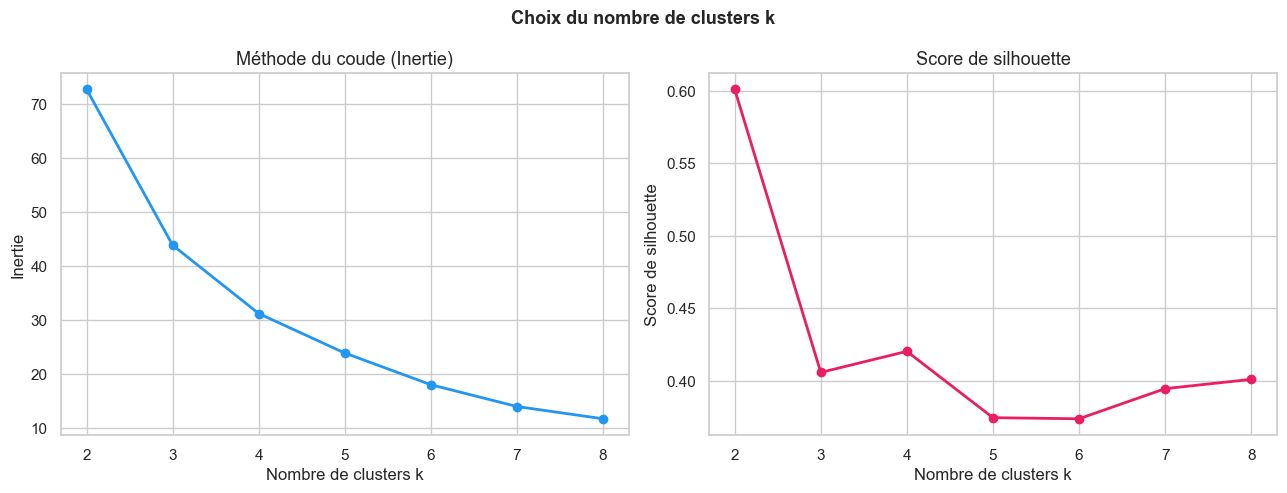


Meilleur k selon le score de silhouette : k = 2


### V.2 Application K-Means avec k = 2


Répartition des équipes par cluster :

  Cluster 0 (27 équipes) :
    Aston Villa, Bournemouth, Brentford, Brighton, Burnley, Cardiff, Crystal Palace, Everton, Fulham, Huddersfield, Hull, Leeds, Leicester, Luton, Middlesbrough, Newcastle United, Norwich, Nottingham Forest, Sheffield United, Southampton, Stoke, Sunderland, Swansea, Watford, West Bromwich Albion, West Ham, Wolverhampton Wanderers

  Cluster 1 (6 équipes) :
    Arsenal, Chelsea, Liverpool, Manchester City, Manchester United, Tottenham

Moyennes par cluster :


,goals,xg,shot,shotOnTarget,deep,ppda
cluster_kmeans,,,,,,
0,1.115,1.168,11.210,3.691,5.220,13.237
1,1.930,1.841,15.356,5.588,10.125,10.051


### V.3 Visualisation des clusters sur le plan ACP

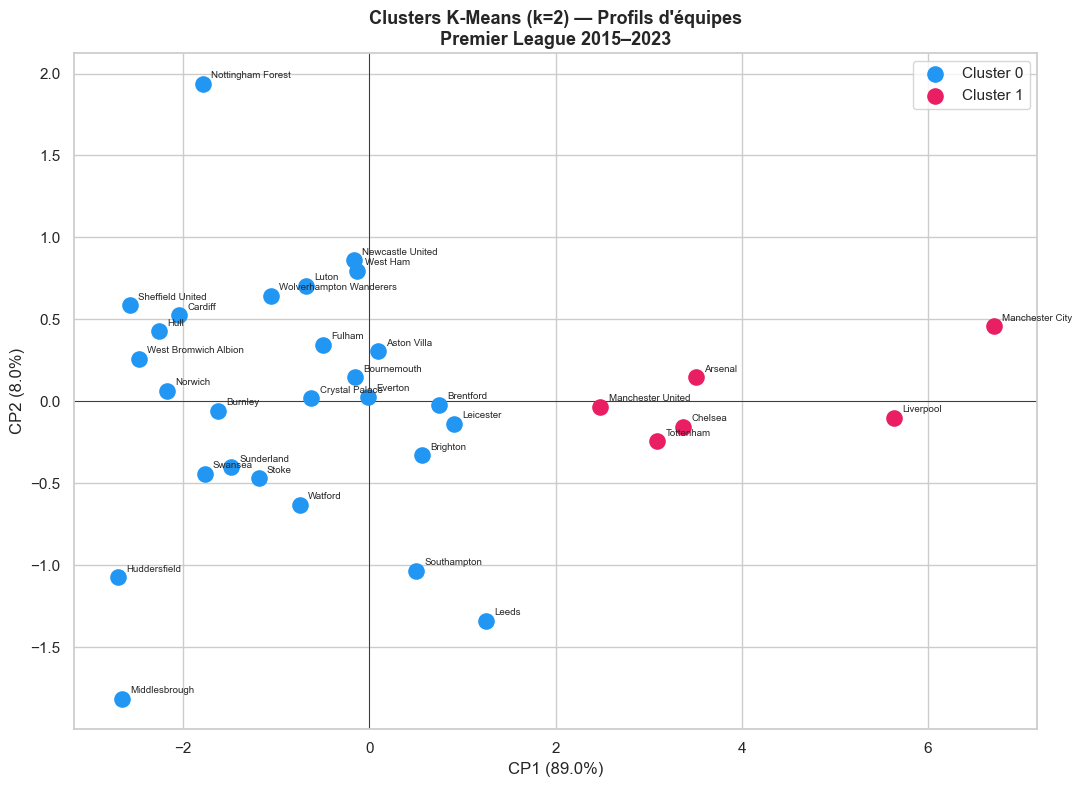

### V.4 CAH — Classification Ascendante Hiérarchique

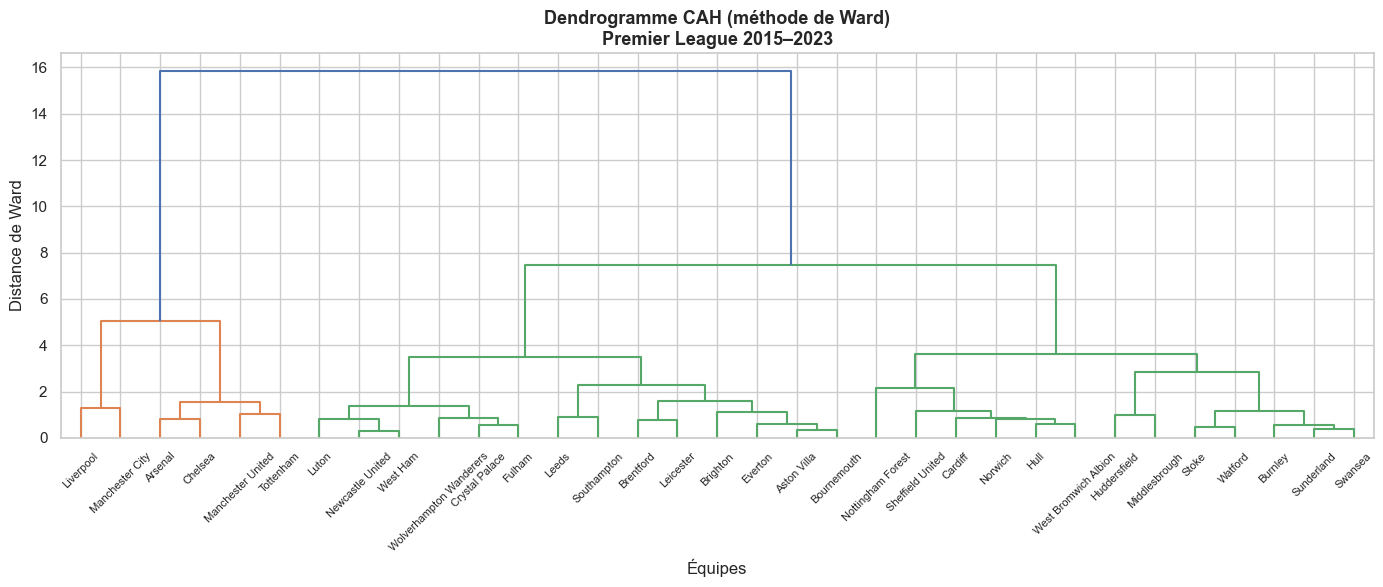


Comparaison K-Means vs CAH :


,cluster_kmeans,cluster_cah
equipe,,
Arsenal,1,1
Aston Villa,0,2
Bournemouth,0,2
Brentford,0,2
Brighton,0,2
Burnley,0,2
Cardiff,0,2
Chelsea,1,1
Crystal Palace,0,2


In [23]:
# ============================================================
# SECTION V : APPRENTISSAGE NON SUPERVISÉ — K-MEANS & CAH
# ============================================================
display(Markdown("## Section V : Apprentissage Non Supervisé — K-Means & CAH"))

# Agrégation des statistiques par équipe sur toute la période
# (on travaille sur les profils d'équipes, pas sur les matchs individuels)
stats_dom = df.groupby('team_h')[['h_goals','h_xg','h_shot','h_shotOnTarget','h_deep','h_ppda']].mean()
stats_ext = df.groupby('team_a')[['a_goals','a_xg','a_shot','a_shotOnTarget','a_deep','a_ppda']].mean()

stats_dom.columns = ['goals','xg','shot','shotOnTarget','deep','ppda']
stats_ext.columns = ['goals','xg','shot','shotOnTarget','deep','ppda']

stats_equipes = ((stats_dom + stats_ext) / 2).dropna()
stats_equipes.index.name = 'equipe'

print("Statistiques moyennes par équipe :")
display(stats_equipes.round(3))

# Standardisation pour le clustering
scaler_cl   = StandardScaler()
X_equipes   = scaler_cl.fit_transform(stats_equipes)

# --- V.1 K-Means — Méthode du coude ---
display(Markdown("### V.1 K-Means — Choix de k (méthode du coude + silhouette)"))

inerties    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_equipes)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_equipes, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Choix du nombre de clusters k", fontsize=13, fontweight='bold')

axes[0].plot(K_range, inerties, 'o-', color=COLORS[0], linewidth=2)
axes[0].set_title("Méthode du coude (Inertie)")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie")

axes[1].plot(K_range, silhouettes, 'o-', color=COLORS[1], linewidth=2)
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score de silhouette")

plt.tight_layout()
plt.savefig('V_choix_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Meilleur k selon silhouette
best_k = K_range[np.argmax(silhouettes)]
print(f"\nMeilleur k selon le score de silhouette : k = {best_k}")

# --- V.2 Application du K-Means avec le meilleur k ---
display(Markdown(f"### V.2 Application K-Means avec k = {best_k}"))

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
stats_equipes['cluster_kmeans'] = kmeans_final.fit_predict(X_equipes)

print("\nRépartition des équipes par cluster :")
for cl in sorted(stats_equipes['cluster_kmeans'].unique()):
    equipes_cl = stats_equipes[stats_equipes['cluster_kmeans'] == cl].index.tolist()
    print(f"\n  Cluster {cl} ({len(equipes_cl)} équipes) :")
    print(f"    {', '.join(equipes_cl)}")

print("\nMoyennes par cluster :")
display(stats_equipes.groupby('cluster_kmeans').mean().round(3))

# --- V.3 Visualisation K-Means sur plan ACP ---
display(Markdown("### V.3 Visualisation des clusters sur le plan ACP"))

pca_cl  = PCA(n_components=2)
X_pca_cl = pca_cl.fit_transform(X_equipes)
ve_cl   = pca_cl.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 8))
for cl in sorted(stats_equipes['cluster_kmeans'].unique()):
    masque = stats_equipes['cluster_kmeans'] == cl
    ax.scatter(X_pca_cl[masque, 0], X_pca_cl[masque, 1],
               c=COLORS[cl % len(COLORS)], s=120,
               label=f'Cluster {cl}', zorder=3)
    for idx, (x_p, y_p) in enumerate(zip(X_pca_cl[masque, 0], X_pca_cl[masque, 1])):
        ax.annotate(stats_equipes[masque].index[idx],
                    (x_p, y_p), textcoords='offset points',
                    xytext=(6, 4), fontsize=7)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(f"CP1 ({ve_cl[0]:.1f}%)")
ax.set_ylabel(f"CP2 ({ve_cl[1]:.1f}%)")
ax.set_title(f"Clusters K-Means (k={best_k}) — Profils d'équipes\nPremier League 2015–2023",
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('V_clusters_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

# --- V.4 CAH — Classification Ascendante Hiérarchique ---
display(Markdown("### V.4 CAH — Classification Ascendante Hiérarchique"))

Z = linkage(X_equipes, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z,
           labels=stats_equipes.index.tolist(),
           leaf_rotation=45,
           leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]),
           ax=ax)
ax.set_title("Dendrogramme CAH (méthode de Ward)\nPremier League 2015–2023",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Équipes")
ax.set_ylabel("Distance de Ward")
plt.tight_layout()
plt.savefig('V_dendrogramme_cah.png', dpi=150, bbox_inches='tight')
plt.show()

# Clusters CAH avec le même k que K-Means pour comparaison
labels_cah = fcluster(Z, t=best_k, criterion='maxclust')
stats_equipes['cluster_cah'] = labels_cah

print("\nComparaison K-Means vs CAH :")
display(stats_equipes[['cluster_kmeans', 'cluster_cah']].head(15))


## Section VI : Analyse des Séries Temporelles

### VI.1 Construction de la série — Buts moyens par mois

Série temporelle : 89 périodes mensuelles


,periode,buts_moyens,periode_dt
0,2015-08,2.475000,2015-08-01
1,2015-09,2.933333,2015-09-01
2,2015-10,2.837838,2015-10-01
3,2015-11,2.727273,2015-11-01
4,2015-12,2.240000,2015-12-01
5,2016-01,2.850000,2016-01-01
6,2016-02,2.526316,2016-02-01
7,2016-03,2.485714,2016-03-01
8,2016-04,2.836735,2016-04-01
9,2016-05,3.428571,2016-05-01


### VI.2 Visualisation de la série brute

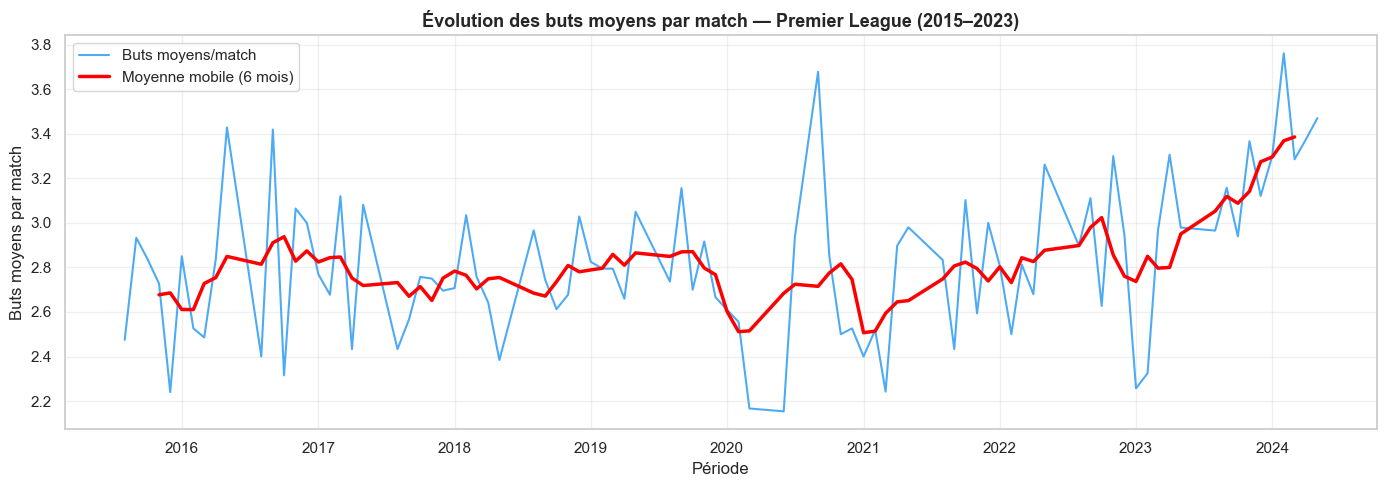

### VI.3 Évolution par saison

,season,buts_dom,buts_ext,buts_totaux,xg_dom,xg_ext
0,2015,1.492,1.208,2.700,1.422,1.160
1,2016,1.597,1.203,2.800,1.458,1.130
2,2017,1.532,1.147,2.679,1.497,1.114
3,2018,1.568,1.253,2.821,1.593,1.263
4,2019,1.516,1.205,2.721,1.535,1.316
5,2020,1.353,1.342,2.695,1.431,1.304
6,2021,1.513,1.305,2.818,1.560,1.279
7,2022,1.634,1.218,2.853,1.669,1.296
8,2023,1.800,1.479,3.279,1.922,1.459


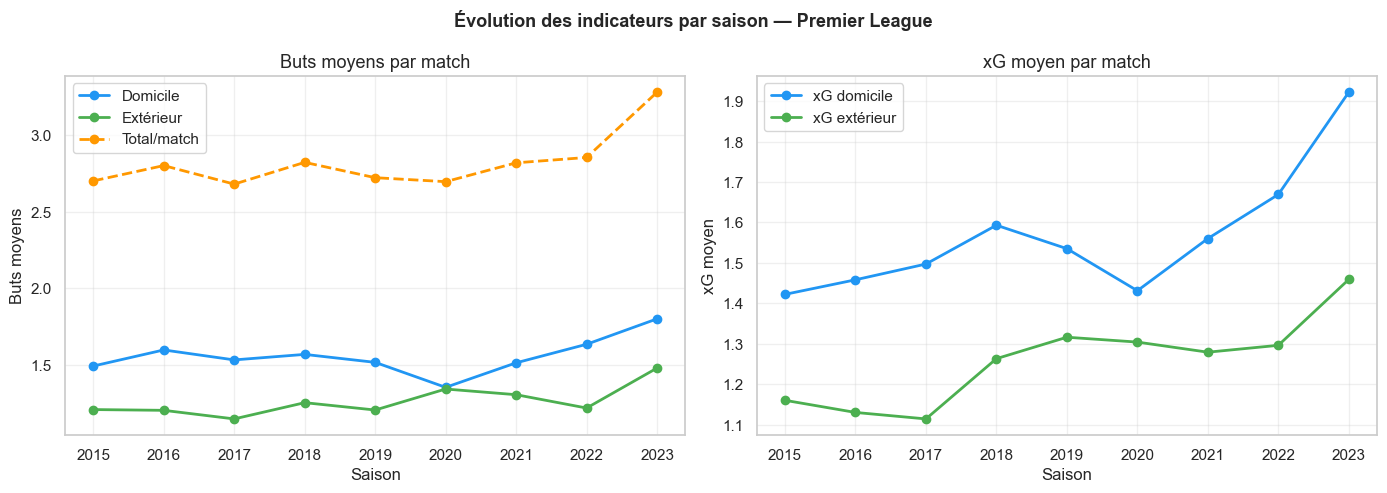

### VI.4 Décomposition de la série (Tendance + Saisonnalité + Résidus)

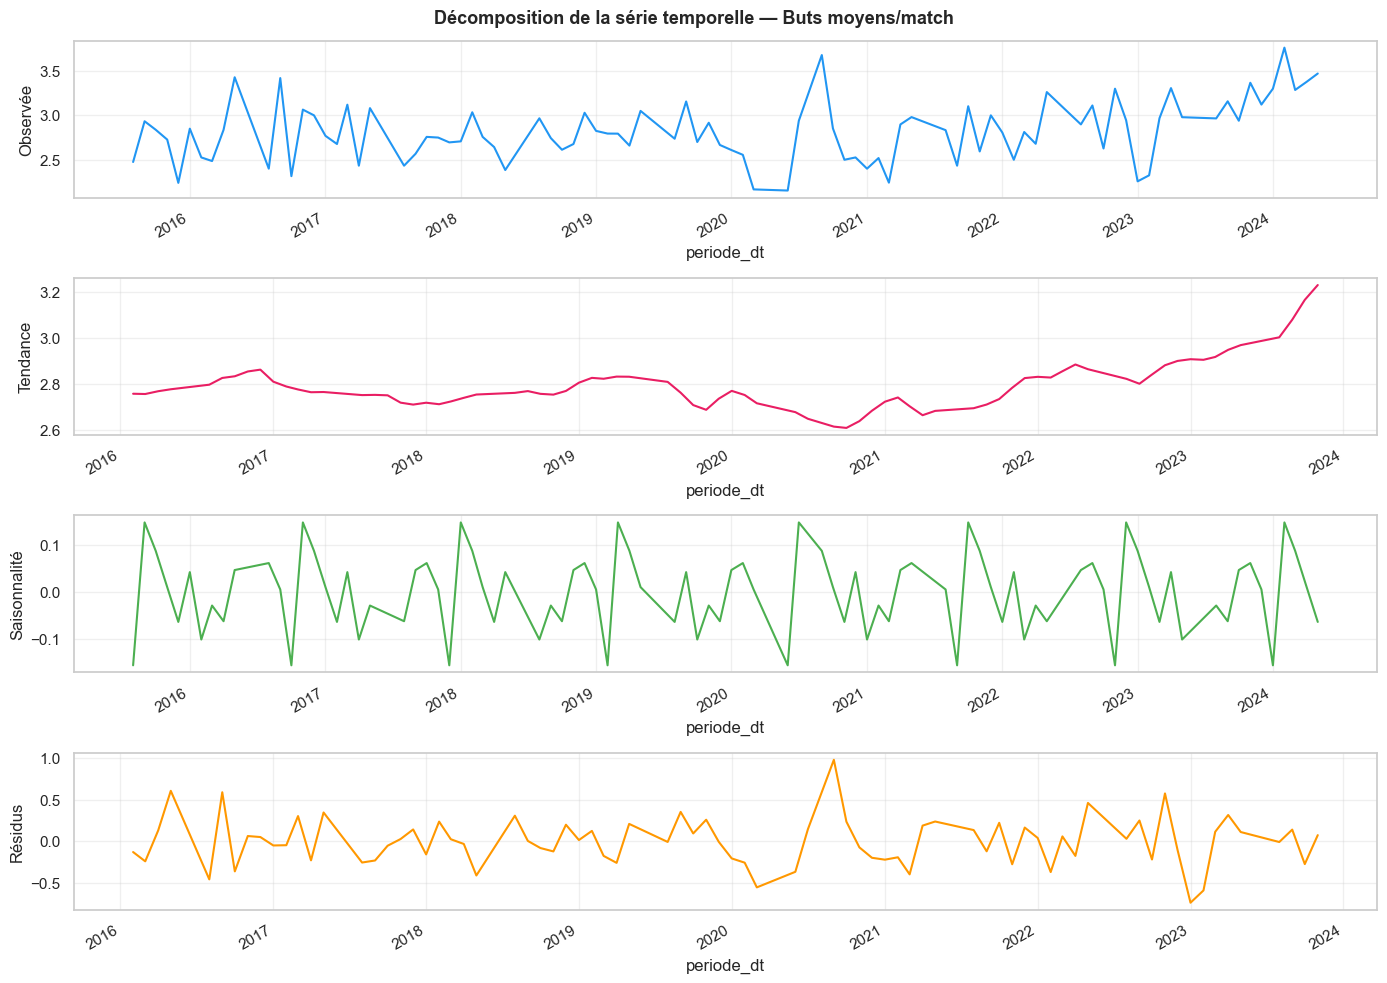

### VI.5 Test de stationnarité — Dickey-Fuller augmenté (ADF)

Test ADF — Hypothèse nulle : la série n'est PAS stationnaire
  Statistique ADF : -7.3881
  p-value         : 0.0000
  Valeurs critiques :
    1% : -3.5069
    5% : -2.8950
    10% : -2.5846

✓ p-value < 0.05 → on rejette H0 : la série EST stationnaire.


### VI.6 Autocorrélogrammes (ACF & PACF)

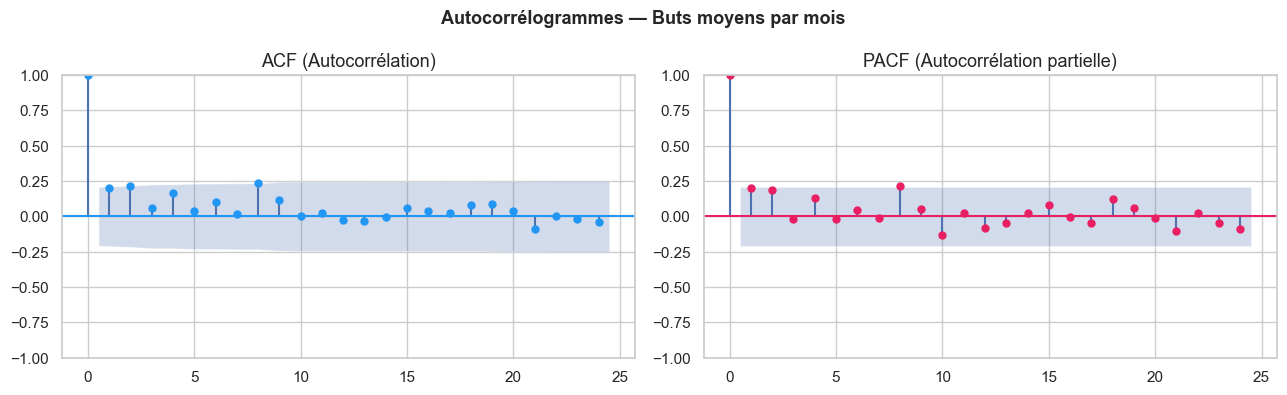

In [24]:
# ============================================================
# SECTION VI : ANALYSE DES SÉRIES TEMPORELLES
# ============================================================
display(Markdown("## Section VI : Analyse des Séries Temporelles"))

# --- VI.1 Construction de la série temporelle ---
display(Markdown("### VI.1 Construction de la série — Buts moyens par mois"))

df['annee_mois'] = df['date'].dt.to_period('M')
serie_buts = (df.groupby('annee_mois')['total_goals']
                .mean()
                .reset_index())
serie_buts.columns = ['periode', 'buts_moyens']
serie_buts['periode_dt'] = serie_buts['periode'].dt.to_timestamp()
serie_buts = serie_buts.sort_values('periode_dt').reset_index(drop=True)

print(f"Série temporelle : {len(serie_buts)} périodes mensuelles")
display(serie_buts.head(10))

# --- VI.2 Visualisation de la série brute ---
display(Markdown("### VI.2 Visualisation de la série brute"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_buts['periode_dt'], serie_buts['buts_moyens'],
        color=COLORS[0], linewidth=1.5, alpha=0.8, label='Buts moyens/match')

# Moyenne mobile sur 6 mois
serie_buts['mm6'] = serie_buts['buts_moyens'].rolling(window=6, center=True).mean()
ax.plot(serie_buts['periode_dt'], serie_buts['mm6'],
        color='red', linewidth=2.5, label='Moyenne mobile (6 mois)')

ax.set_title("Évolution des buts moyens par match — Premier League (2015–2023)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Période")
ax.set_ylabel("Buts moyens par match")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('VI_serie_brute.png', dpi=150, bbox_inches='tight')
plt.show()

# --- VI.3 Évolution par saison ---
display(Markdown("### VI.3 Évolution par saison"))

serie_saison = df.groupby('season').agg(
    buts_dom    = ('h_goals',      'mean'),
    buts_ext    = ('a_goals',      'mean'),
    buts_totaux = ('total_goals',  'mean'),
    xg_dom      = ('h_xg',         'mean'),
    xg_ext      = ('a_xg',         'mean'),
).round(3).reset_index()

display(serie_saison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Évolution des indicateurs par saison — Premier League",
             fontsize=13, fontweight='bold')

# Buts
axes[0].plot(serie_saison['season'], serie_saison['buts_dom'],
             'o-', color=COLORS[0], linewidth=2, label='Domicile')
axes[0].plot(serie_saison['season'], serie_saison['buts_ext'],
             'o-', color=COLORS[2], linewidth=2, label='Extérieur')
axes[0].plot(serie_saison['season'], serie_saison['buts_totaux'],
             'o--', color=COLORS[3], linewidth=2, label='Total/match')
axes[0].set_title("Buts moyens par match")
axes[0].set_xlabel("Saison")
axes[0].set_ylabel("Buts moyens")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# xG
axes[1].plot(serie_saison['season'], serie_saison['xg_dom'],
             'o-', color=COLORS[0], linewidth=2, label='xG domicile')
axes[1].plot(serie_saison['season'], serie_saison['xg_ext'],
             'o-', color=COLORS[2], linewidth=2, label='xG extérieur')
axes[1].set_title("xG moyen par match")
axes[1].set_xlabel("Saison")
axes[1].set_ylabel("xG moyen")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('VI_evolution_saison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- VI.4 Décomposition de la série temporelle ---
display(Markdown("### VI.4 Décomposition de la série (Tendance + Saisonnalité + Résidus)"))

serie_ts = serie_buts.set_index('periode_dt')['buts_moyens'].dropna()

decomp = seasonal_decompose(serie_ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle("Décomposition de la série temporelle — Buts moyens/match",
             fontsize=13, fontweight='bold')

decomp.observed.plot(ax=axes[0], color=COLORS[0])
axes[0].set_ylabel("Observée")
axes[0].set_title("")

decomp.trend.plot(ax=axes[1], color=COLORS[1])
axes[1].set_ylabel("Tendance")

decomp.seasonal.plot(ax=axes[2], color=COLORS[2])
axes[2].set_ylabel("Saisonnalité")

decomp.resid.plot(ax=axes[3], color=COLORS[3])
axes[3].set_ylabel("Résidus")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('VI_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# --- VI.5 Test de stationnarité (ADF) ---
display(Markdown("### VI.5 Test de stationnarité — Dickey-Fuller augmenté (ADF)"))

resultat_adf = adfuller(serie_ts.dropna())
print("Test ADF — Hypothèse nulle : la série n'est PAS stationnaire")
print(f"  Statistique ADF : {resultat_adf[0]:.4f}")
print(f"  p-value         : {resultat_adf[1]:.4f}")
print(f"  Valeurs critiques :")
for cle, val in resultat_adf[4].items():
    print(f"    {cle} : {val:.4f}")

if resultat_adf[1] < 0.05:
    print("\n✓ p-value < 0.05 → on rejette H0 : la série EST stationnaire.")
else:
    print("\n✗ p-value ≥ 0.05 → on ne rejette pas H0 : la série N'EST PAS stationnaire.")

# --- VI.6 Autocorrélogrammes ACF et PACF ---
display(Markdown("### VI.6 Autocorrélogrammes (ACF & PACF)"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Autocorrélogrammes — Buts moyens par mois",
             fontsize=13, fontweight='bold')

plot_acf(serie_ts.dropna(),  lags=24, ax=axes[0], color=COLORS[0])
axes[0].set_title("ACF (Autocorrélation)")

plot_pacf(serie_ts.dropna(), lags=24, ax=axes[1], color=COLORS[1])
axes[1].set_title("PACF (Autocorrélation partielle)")

plt.tight_layout()
plt.savefig('VI_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# ============================================================
# RÉCAPITULATIF FINAL
# ============================================================
display(Markdown("## Récapitulatif — Analyses réalisées"))

print("=" * 60)
print("  RÉCAPITULATIF DES ANALYSES")
print("=" * 60)
etapes = [
    ("Section II",  "ACP",
     f"{n_comp} composantes retenues ({variance_cumulee[n_comp-1]:.1f}% de variance)"),
    ("Section III", "AFC",   "Non applicable (pas de tableau de contingence)"),
    ("Section IV",  "ACM",   "Non applicable (une seule variable catégorielle)"),
    ("Section V",   "K-Means", f"k={best_k} clusters identifiés + dendrogramme CAH"),
    ("Section VI",  "Séries temporelles",
     "Décomposition + test ADF + ACF/PACF"),
]
for section, analyse, detail in etapes:
    print(f"  {section:<12} {analyse:<20} → {detail}")
print("=" * 60)
print("\nFichiers graphiques sauvegardés :")
graphiques = [
    'II_acp_variance.png', 'II_cercle_correlations.png', 'II_plan_factoriel.png',
    'V_choix_k.png', 'V_clusters_kmeans.png', 'V_dendrogramme_cah.png',
    'VI_serie_brute.png', 'VI_evolution_saison.png',
    'VI_decomposition.png', 'VI_acf_pacf.png'
]
for g in graphiques:
    print(f"  → {g}")
print("\nProchaine étape : Application (régression logistique) + Rapport final")

## Récapitulatif — Analyses réalisées

  RÉCAPITULATIF DES ANALYSES
  Section II   ACP                  → 4 composantes retenues (75.1% de variance)
  Section III  AFC                  → Non applicable (pas de tableau de contingence)
  Section IV   ACM                  → Non applicable (une seule variable catégorielle)
  Section V    K-Means              → k=2 clusters identifiés + dendrogramme CAH
  Section VI   Séries temporelles   → Décomposition + test ADF + ACF/PACF

Fichiers graphiques sauvegardés :
  → II_acp_variance.png
  → II_cercle_correlations.png
  → II_plan_factoriel.png
  → V_choix_k.png
  → V_clusters_kmeans.png
  → V_dendrogramme_cah.png
  → VI_serie_brute.png
  → VI_evolution_saison.png
  → VI_decomposition.png
  → VI_acf_pacf.png

Prochaine étape : Application (régression logistique) + Rapport final


## 7.2 Variables utilisées et modèle choisi

Variables explicatives (features) :
['h_xg', 'a_xg', 'h_shot', 'a_shot', 'h_shotOnTarget', 'a_shotOnTarget', 'h_deep', 'a_deep', 'h_ppda', 'a_ppda']

Variable cible : result (V = Victoire domicile, N = Nul, D = Défaite domicile)

Distribution de la cible :
result
V    1536
D    1091
N     793
Name: count, dtype: int64
result
V    44.9
D    31.9
N    23.2
Name: proportion, dtype: float64

Ensemble d'entraînement : 2736 matchs (80.0%)
Ensemble de test        : 684 matchs (20.0%)

Modèle entraîné : Régression Logistique (multinomiale)


## 7.3 Résultats et évaluation du modèle

Accuracy du modèle : 0.6579 (65.79%)
Accuracy modèle naïf (toujours 'V') : 0.4488 (44.88%)
Gain par rapport au modèle naïf : +20.91 points

--- Matrice de confusion ---
        Prédit V  Prédit N  Prédit D
Réel V       258        12        37
Réel N        90        20        49
Réel D        31        15       172


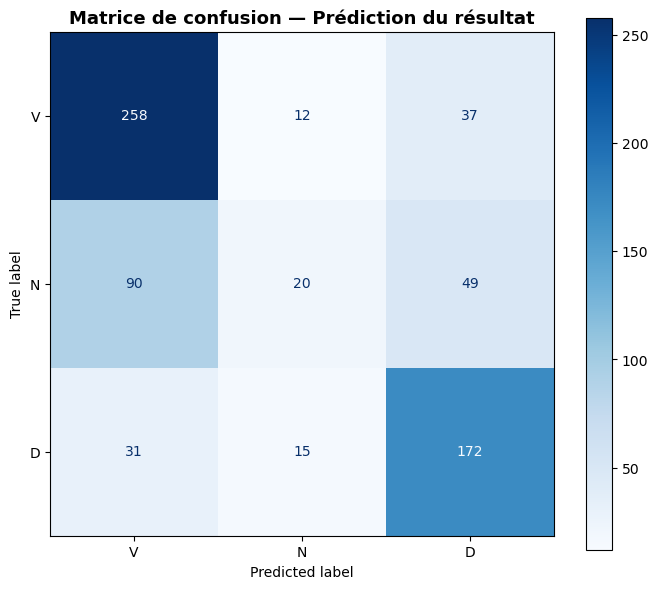


--- Rapport de classification ---
                   precision    recall  f1-score   support

 Défaite dom. (D)       0.67      0.79      0.72       218
          Nul (N)       0.43      0.13      0.19       159
Victoire dom. (V)       0.68      0.84      0.75       307

         accuracy                           0.66       684
        macro avg       0.59      0.59      0.56       684
     weighted avg       0.62      0.66      0.61       684



## 7.4 Interprétation — Importance des variables

Coefficients du modèle (par classe) :


,h_xg,a_xg,h_shot,a_shot,h_shotOnTarget,a_shotOnTarget,h_deep,a_deep,h_ppda,a_ppda
D,-0.701,0.765,0.417,-0.508,-0.551,0.633,-0.017,0.111,-0.015,0.053
N,-0.059,-0.068,0.212,0.179,-0.115,-0.127,-0.069,-0.051,-0.051,-0.035
V,0.760,-0.697,-0.628,0.329,0.666,-0.507,0.086,-0.061,0.065,-0.017



Importance moyenne des variables (valeur absolue des coefficients) :
a_xg              0.510
h_xg              0.507
h_shotOnTarget    0.444
a_shotOnTarget    0.422
h_shot            0.419
a_shot            0.339
a_deep            0.074
h_deep            0.057
h_ppda            0.043
a_ppda            0.035
dtype: float64


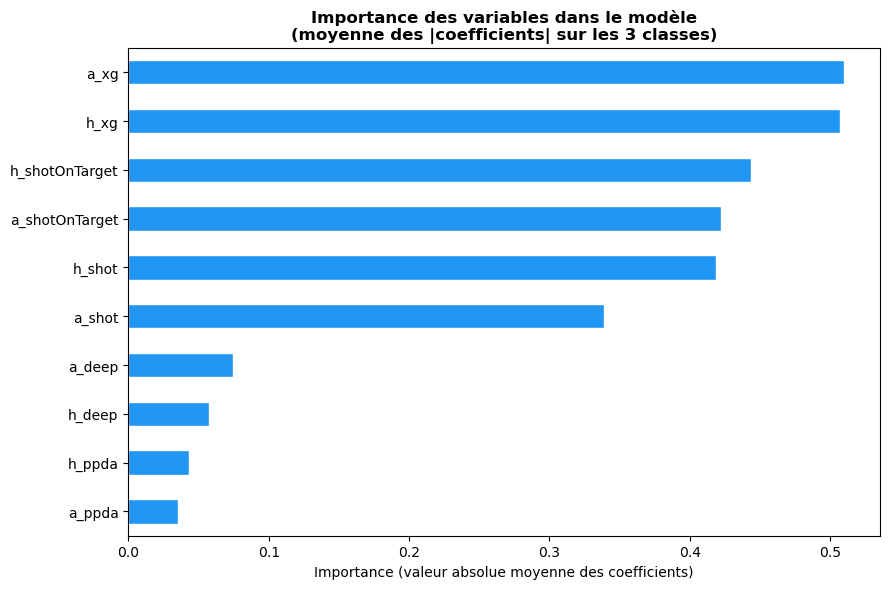


✓ Application terminée.
  Fichiers sauvegardés : VII_matrice_confusion.png, VII_importance_variables.png


In [2]:
# ============================================================
# PROJET ANALYSE DE DONNÉES — EPT 2025-2026
# Chapitre 7 : Application — Prédiction du résultat d'un match
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

from IPython.display import display, Markdown

# Chargement des données prétraitées
df = pd.read_csv(r'df_pretraite.csv')

COLORS = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

# ============================================================
# 7.2 — VARIABLES ET MODÈLE
# ============================================================
display(Markdown("## 7.2 Variables utilisées et modèle choisi"))

# Variables explicatives : uniquement des stats disponibles/prédictibles
# On utilise le xG (plus stable que les buts bruts) et les stats de jeu
features = ['h_xg', 'a_xg', 'h_shot', 'a_shot',
            'h_shotOnTarget', 'a_shotOnTarget',
            'h_deep', 'a_deep', 'h_ppda', 'a_ppda']

X = df[features]
y = df['result']  # V / N / D

print("Variables explicatives (features) :")
print(features)
print(f"\nVariable cible : result (V = Victoire domicile, N = Nul, D = Défaite domicile)")
print(f"\nDistribution de la cible :")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3) * 100)

# Split train/test stratifié (rappel TP2 : préserver les proportions de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nEnsemble d'entraînement : {len(X_train)} matchs ({len(X_train)/len(X)*100:.1f}%)")
print(f"Ensemble de test        : {len(X_test)} matchs ({len(X_test)/len(X)*100:.1f}%)")

# Standardisation (indispensable pour la régression logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèle : régression logistique multinomiale
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("\nModèle entraîné : Régression Logistique (multinomiale)")

# ============================================================
# 7.3 — RÉSULTATS ET ÉVALUATION
# ============================================================
display(Markdown("## 7.3 Résultats et évaluation du modèle"))

y_pred = model.predict(X_test_scaled)

# Accuracy globale
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy du modèle : {accuracy:.4f} ({accuracy*100:.2f}%)")

# Comparaison avec un modèle naïf (prédit toujours la classe majoritaire)
classe_majoritaire = y_train.value_counts().idxmax()
accuracy_naive = (y_test == classe_majoritaire).mean()
print(f"Accuracy modèle naïf (toujours '{classe_majoritaire}') : {accuracy_naive:.4f} ({accuracy_naive*100:.2f}%)")
print(f"Gain par rapport au modèle naïf : +{(accuracy - accuracy_naive)*100:.2f} points")

# Matrice de confusion
print("\n--- Matrice de confusion ---")
cm = confusion_matrix(y_test, y_pred, labels=['V', 'N', 'D'])
print(pd.DataFrame(cm, index=['Réel V', 'Réel N', 'Réel D'],
                    columns=['Prédit V', 'Prédit N', 'Prédit D']))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['V', 'N', 'D'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title("Matrice de confusion — Prédiction du résultat", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('VII_matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Rapport de classification complet
print("\n--- Rapport de classification ---")
print(classification_report(y_test, y_pred, target_names=['Défaite dom. (D)', 'Nul (N)', 'Victoire dom. (V)']))

# ============================================================
# 7.4 — INTERPRÉTATION : IMPORTANCE DES VARIABLES
# ============================================================
display(Markdown("## 7.4 Interprétation — Importance des variables"))

# Pour une régression logistique multinomiale, on a un jeu de coefficients par classe
coefs = pd.DataFrame(
    model.coef_,
    columns=features,
    index=model.classes_
)
print("Coefficients du modèle (par classe) :")
display(coefs.round(3))

# Importance moyenne (valeur absolue moyenne sur les 3 classes)
importance = coefs.abs().mean(axis=0).sort_values(ascending=False)
print("\nImportance moyenne des variables (valeur absolue des coefficients) :")
print(importance.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind='barh', ax=ax, color=COLORS[0], edgecolor='white')
ax.set_title("Importance des variables dans le modèle\n(moyenne des |coefficients| sur les 3 classes)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Importance (valeur absolue moyenne des coefficients)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('VII_importance_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Application terminée.")
print("  Fichiers sauvegardés : VII_matrice_confusion.png, VII_importance_variables.png")